## 1.1 Needed Packages

In [1]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Importing pakages

#Data Processing
import numpy as np
import pandas as pd
import math

#Visualization
import seaborn as sns
import matplotlib.pyplot as plt

#Data processing modules
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

#Machine Learing Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC


## 1.2 Data Loading

In [3]:
data = 'ESS.csv'
df = pd.read_csv(data)
df_clean = df.drop(['name','essround','edition','proddate','idno','dweight','anweight','prob', 'stratum','psu','pspwght','pweight'], axis=1)
# Define missing value codes for each variable
missing_map = {
    'bctprd': [7, 8, 9],
    'gndr': [9],
    'agea': [999],
    'eduyrs': [77, 88, 99],
    'netusoft': [7,8,9],
    'nwspol': [7777,8888,9999]
}

# Variables with 66, 77, 88, 99 as missing
value_vars = ['ipcrtiva', 'impricha', 'ipeqopta', 'ipshabta', 'impsafea', 'impdiffa',
              'ipfrulea', 'ipudrsta', 'ipmodsta', 'ipgdtima', 'impfreea', 'iphlppla',
              'ipsucesa', 'ipstrgva', 'ipadvnta', 'ipbhprpa', 'iprspota', 'iplylfra',
              'impenva', 'imptrada', 'impfuna']

for var in value_vars:
    missing_map[var] = [66, 77, 88, 99]

# Replace defined missing codes with NaN
for col, codes in missing_map.items():
    df_clean[col] = df_clean[col].replace(codes, np.nan)

df_clean.rename(columns={'agea': 'age', 'nwspol':'news', 'eduyrs': 'education_years', 'gndr': 'gender', 'cntry':'country', 'bctprd':'boycott', 'netusoft': 'internet'}, inplace=True)

df_clean['boycott'] = df_clean['boycott'].replace(2, 0)
df_clean = df_clean.dropna(subset=['boycott'])


## 1.3 EDA

In [4]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 49806 entries, 0 to 50115
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          49806 non-null  str    
 1   news             49090 non-null  float64
 2   internet         49756 non-null  float64
 3   boycott          49806 non-null  float64
 4   gender           49806 non-null  int64  
 5   age              49429 non-null  float64
 6   education_years  48943 non-null  float64
 7   ipcrtiva         48898 non-null  float64
 8   impricha         48991 non-null  float64
 9   ipeqopta         48945 non-null  float64
 10  ipshabta         48918 non-null  float64
 11  impsafea         49032 non-null  float64
 12  impdiffa         48959 non-null  float64
 13  ipfrulea         48625 non-null  float64
 14  ipudrsta         48845 non-null  float64
 15  ipmodsta         48919 non-null  float64
 16  ipgdtima         48965 non-null  float64
 17  impfreea         48995 non-n

In [5]:
df_clean.describe()

,news,internet,boycott,gender,age,education_years,ipcrtiva,impricha,ipeqopta,ipshabta,...,iphlppla,ipsucesa,ipstrgva,ipadvnta,ipbhprpa,iprspota,iplylfra,impenva,imptrada,impfuna
count,49090.000000,49756.000000,49806.000000,49806.000000,49429.000000,48943.000000,48898.000000,48991.000000,48945.000000,48918.000000,...,49017.000000,48847.000000,48651.000000,48929.000000,48857.000000,48778.000000,48994.000000,48983.000000,48967.000000,48953.000000
mean,97.757547,4.199875,0.185259,1.539112,51.606425,13.248554,2.621089,4.071360,2.048258,3.225255,...,2.192872,3.164903,2.242667,3.813730,2.635405,3.166756,1.970935,2.173264,2.709274,2.959962
std,159.101565,1.418989,0.388511,0.498473,18.665848,4.016341,1.290143,1.360125,1.075486,1.411399,...,1.021043,1.377196,1.166905,1.455888,1.249533,1.387369,0.978976,1.059117,1.364465,1.332657
min,0.000000,1.000000,0.000000,1.000000,15.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,30.000000,4.000000,0.000000,1.000000,37.000000,11.000000,2.000000,3.000000,1.000000,2.000000,...,1.000000,2.000000,1.000000,3.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000
50%,60.000000,5.000000,0.000000,2.000000,52.000000,13.000000,2.000000,4.000000,2.000000,3.000000,...,2.000000,3.000000,2.000000,4.000000,2.000000,3.000000,2.000000,2.000000,2.000000,3.000000
75%,120.000000,5.000000,0.000000,2.000000,67.000000,16.000000,3.000000,5.000000,3.000000,4.000000,...,3.000000,4.000000,3.000000,5.000000,3.000000,4.000000,2.000000,3.000000,4.000000,4.000000
max,1440.000000,5.000000,1.000000,2.000000,90.000000,69.000000,6.000000,6.000000,6.000000,6.000000,...,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000


In [6]:
df_clean.head(5)

,country,news,internet,boycott,gender,age,education_years,ipcrtiva,impricha,ipeqopta,...,iphlppla,ipsucesa,ipstrgva,ipadvnta,ipbhprpa,iprspota,iplylfra,impenva,imptrada,impfuna
0,AT,90.0,5.0,0.0,1,65.0,12.0,3.0,5.0,2.0,...,2.0,3.0,2.0,5.0,2.0,2.0,2.0,2.0,3.0,3.0
1,AT,90.0,5.0,1.0,2,21.0,14.0,2.0,4.0,2.0,...,1.0,4.0,2.0,4.0,2.0,4.0,1.0,1.0,4.0,2.0
2,AT,30.0,5.0,1.0,2,53.0,16.0,1.0,4.0,1.0,...,1.0,3.0,2.0,4.0,3.0,3.0,1.0,1.0,3.0,2.0
3,AT,15.0,1.0,0.0,2,78.0,14.0,3.0,4.0,2.0,...,2.0,3.0,3.0,4.0,3.0,3.0,2.0,2.0,2.0,3.0
4,AT,60.0,5.0,0.0,1,64.0,12.0,3.0,4.0,2.0,...,2.0,2.0,2.0,4.0,2.0,2.0,2.0,2.0,2.0,2.0


In [7]:

df_clean[['gender', 'boycott']] = df_clean[['gender', 'boycott']].astype('object')
numerical_cols = df_clean.select_dtypes(include = 'float64').columns
categorical_cols = df_clean.select_dtypes(include = 'object').columns

print(numerical_cols.values)
print(categorical_cols.values)



<StringArray>
[           'news',        'internet',             'age', 'education_years',
        'ipcrtiva',        'impricha',        'ipeqopta',        'ipshabta',
        'impsafea',        'impdiffa',        'ipfrulea',        'ipudrsta',
        'ipmodsta',        'ipgdtima',        'impfreea',        'iphlppla',
        'ipsucesa',        'ipstrgva',        'ipadvnta',        'ipbhprpa',
        'iprspota',        'iplylfra',         'impenva',        'imptrada',
         'impfuna']
Length: 25, dtype: str
<StringArray>
['country', 'boycott', 'gender']
Length: 3, dtype: str


/var/folders/p5/dd0mn9h16750wt2b1yj0qkf80000gn/T/ipykernel_95273/284300885.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include = 'object').columns


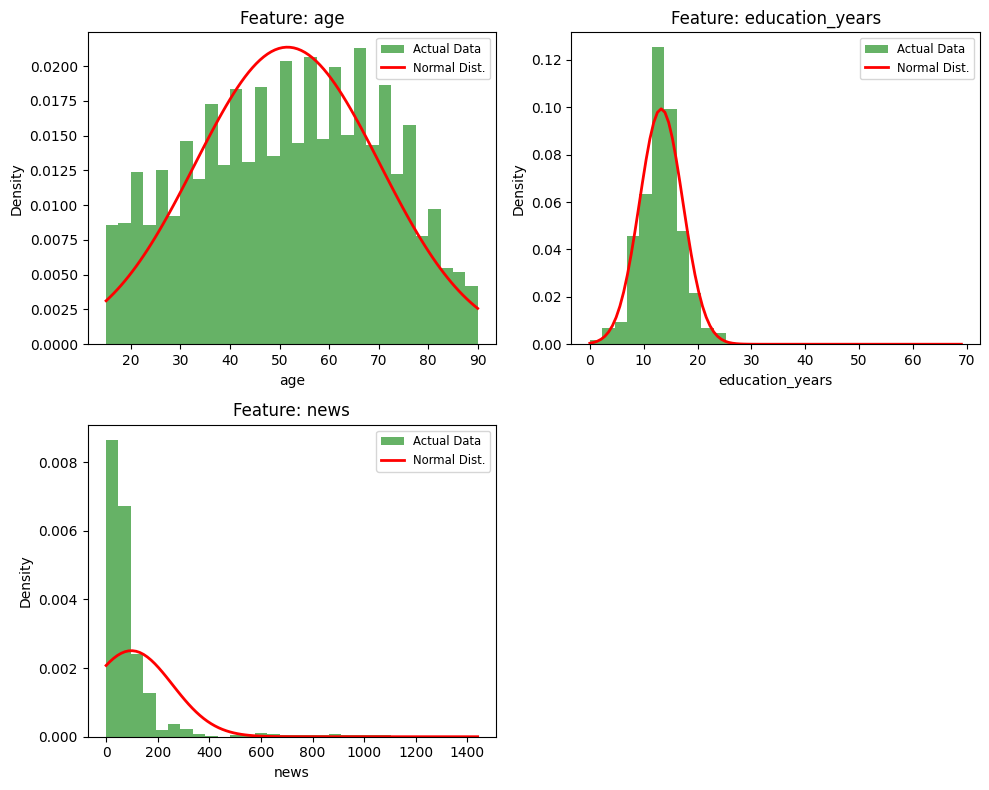

In [8]:

# 1. Define  features 
selected_cols = ['age', 'education_years', 'news'] 
# If you want to run all numerical columns, use: selected_cols = numerical_cols
X = df_clean.drop('boycott', axis=1)
y = df_clean['boycott'].astype(int)

# 2. Calculate dynamic grid dimensions
n_features = len(selected_cols)
n_cols = 2  # You can change this to 3 or 4 for more columns
n_rows = math.ceil(n_features / n_cols)

# 3. Initialize the figure
fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))

# Ensure ax is an array even if there is only 1 plot
if n_features > 1:
    ax = ax.flatten()
else:
    ax = [ax]

# 4. Loop through each feature to create the plots
for c, column in enumerate(selected_cols):
    # Calculate mean (mu) and standard deviation (sigma)
    mu, sigma = X[column].mean(), X[column].std()
    
    # Plot Histogram: density=True normalizes the y-axis to total 1 (Density)
    # Using 20-30 bins is standard for seeing the distribution shape
    count, bins_edges, ignored = ax[c].hist(X[column], bins=30, density=True, 
                                            alpha=0.6, color='g', label='Actual Data')

    # Generate smooth X-values for the Normal Distribution curve
    # This prevents the "jagged" red line seen when using histogram bins
    x_smooth = np.linspace(X[column].min(), X[column].max(), 100)
    
    # Calculate the Probability Density Function (PDF)
    pdf = 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-(x_smooth - mu) ** 2 / (2 * sigma ** 2))
    
    # Plot the Normal Distribution curve
    ax[c].plot(x_smooth, pdf, linewidth=2, color='r', label='Normal Dist.')

    # Formatting
    ax[c].set_title(f'Feature: {column}')
    ax[c].set_xlabel(column)
    ax[c].set_ylabel('Density')
    ax[c].legend(fontsize='small')

# 5. Hide unused axes (if n_features < total grid slots)
for i in range(n_features, len(ax)):
    ax[i].axis('off')

# 6. Final layout and save
plt.tight_layout()
plt.show()

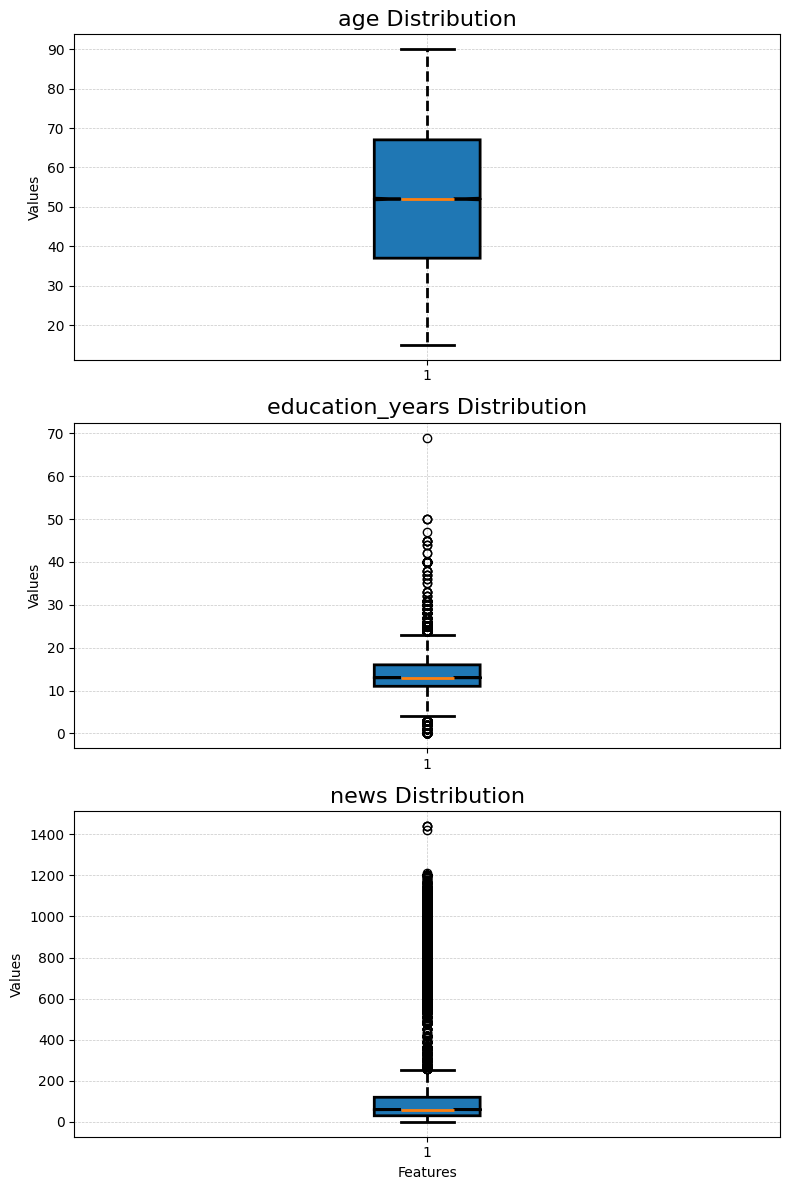

In [9]:
box_cols = ['age', 'education_years', 'news']

# Convert to numeric + drop missing values
box_data = X[box_cols].apply(pd.to_numeric, errors='coerce').dropna()

fig, axes = plt.subplots(3, 1, figsize=(8, 12))

boxprops = dict(linestyle='-', linewidth=2)
medianprops = dict(linestyle='-', linewidth=2)
whiskerprops = dict(linestyle='--', linewidth=2)
capprops = dict(linestyle='-', linewidth=2)

for i, col in enumerate(box_cols):
    axes[i].boxplot(
        box_data[col].values,
        notch=True,
        patch_artist=True,
        boxprops=boxprops,
        medianprops=medianprops,
        whiskerprops=whiskerprops,
        capprops=capprops
    )

    axes[i].set_title(f'{col} Distribution', fontsize=16)
    axes[i].set_ylabel('Values')
    axes[i].grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

axes[-1].set_xlabel('Features')

plt.tight_layout()
plt.show()
#plt.savefig('Age_Eduyrs_boxplot.pdf', dpi=300)



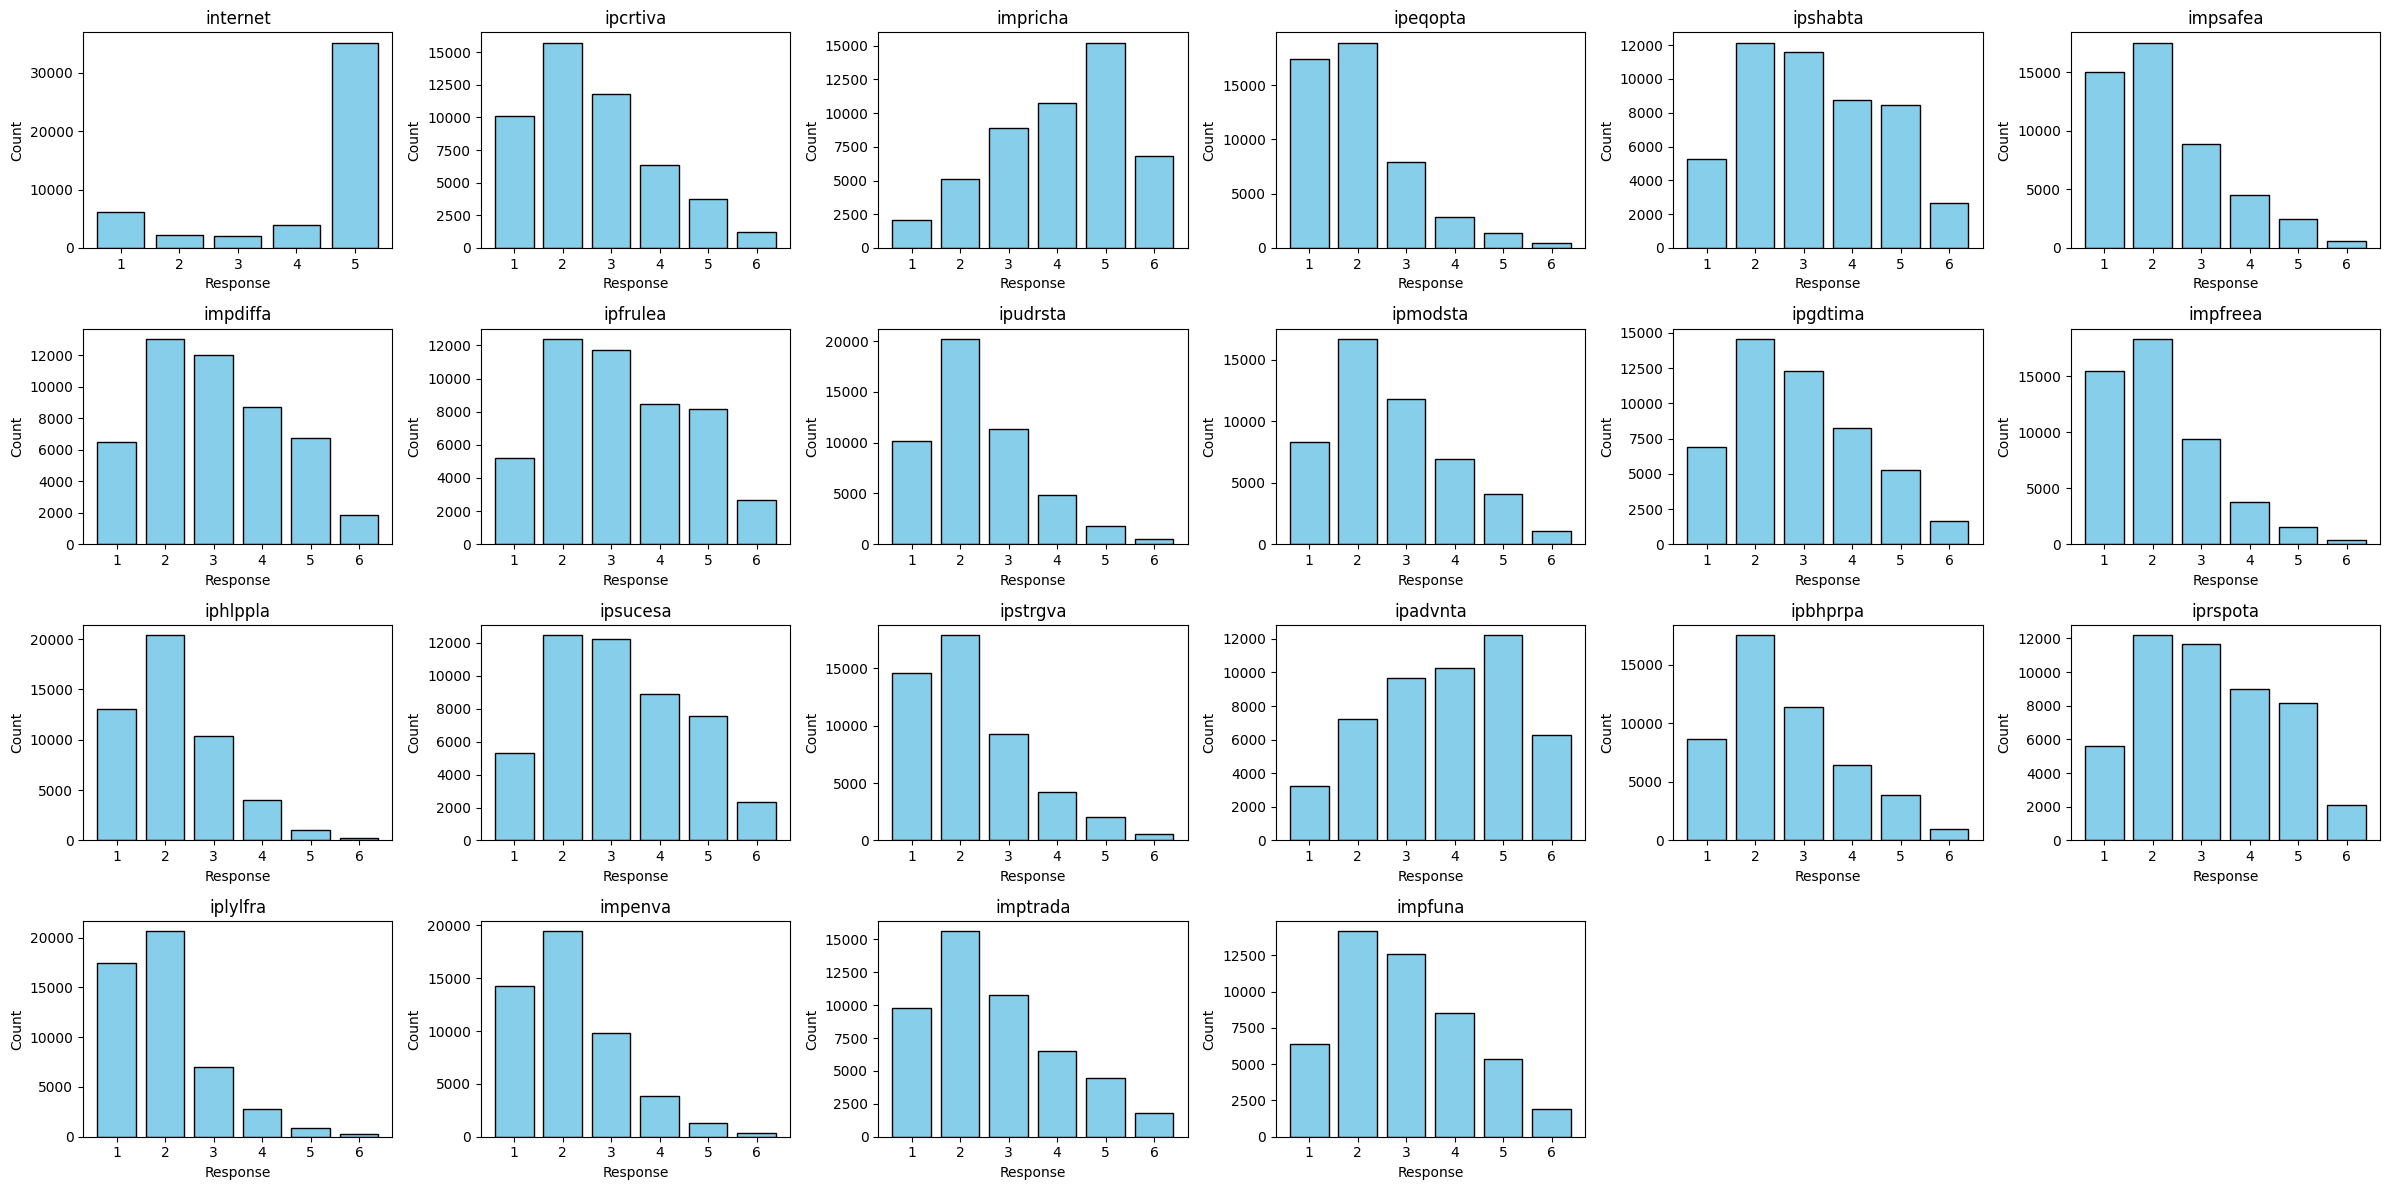

In [10]:



likert_cols = [c for c in numerical_cols if c not in ['age', 'education_years', 'news']]

n_cols = 6
n_rows = int(np.ceil(len(likert_cols) / n_cols))

fig, ax = plt.subplots(n_rows, n_cols, figsize=(24, 12))
ax = ax.flatten()

for i, column in enumerate(likert_cols):
    counts = X[column].value_counts().sort_index()
    
    # Plot bar chart
    ax[i].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
    
    # Titles and labels
    ax[i].set_title(column)
    ax[i].set_xlabel('Response')
    ax[i].set_ylabel('Count')
    
    # Dynamically set x-ticks based on actual responses
    ax[i].set_xticks(counts.index)
    
# Delete any extra empty axes
for j in range(i + 1, len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()
# Optional: save figure
# plt.savefig('Likert_item_counts.pdf', dpi=300)

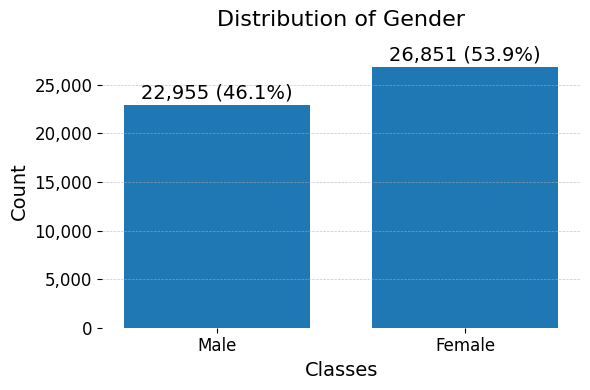

In [11]:
# Count samples in each class (bctprd = 1 or 2)
class_counts = [
    np.sum(df_clean['gender'] == 1),
    np.sum(df_clean['gender'] == 2)
]

class_labels = ['Male', 'Female']

# Calculate percentages
total = sum(class_counts)
class_percents = [(count / total) * 100 for count in class_counts]

# Bar Plot
plt.figure(figsize=(6, 4))
bars = plt.bar(class_labels, class_counts, width=0.75)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7, axis='y')

# Title and labels
plt.title('Distribution of Gender', fontsize=16, pad=20)  # space above bars
plt.xlabel('Classes', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add value labels above the bars with count and percentage
for bar, percent in zip(bars, class_percents):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + max(class_counts)*0.01,  # slightly above the bar
        f"{int(yval):,} ({percent:.1f}%)",  # count with thousands separator and %
        ha='center',
        va='bottom',
        fontsize=14
    )

# Format y-axis with thousands separator
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Remove spines
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
#plt.savefig('gender_class_dist.pdf', dpi=300)
plt.show()


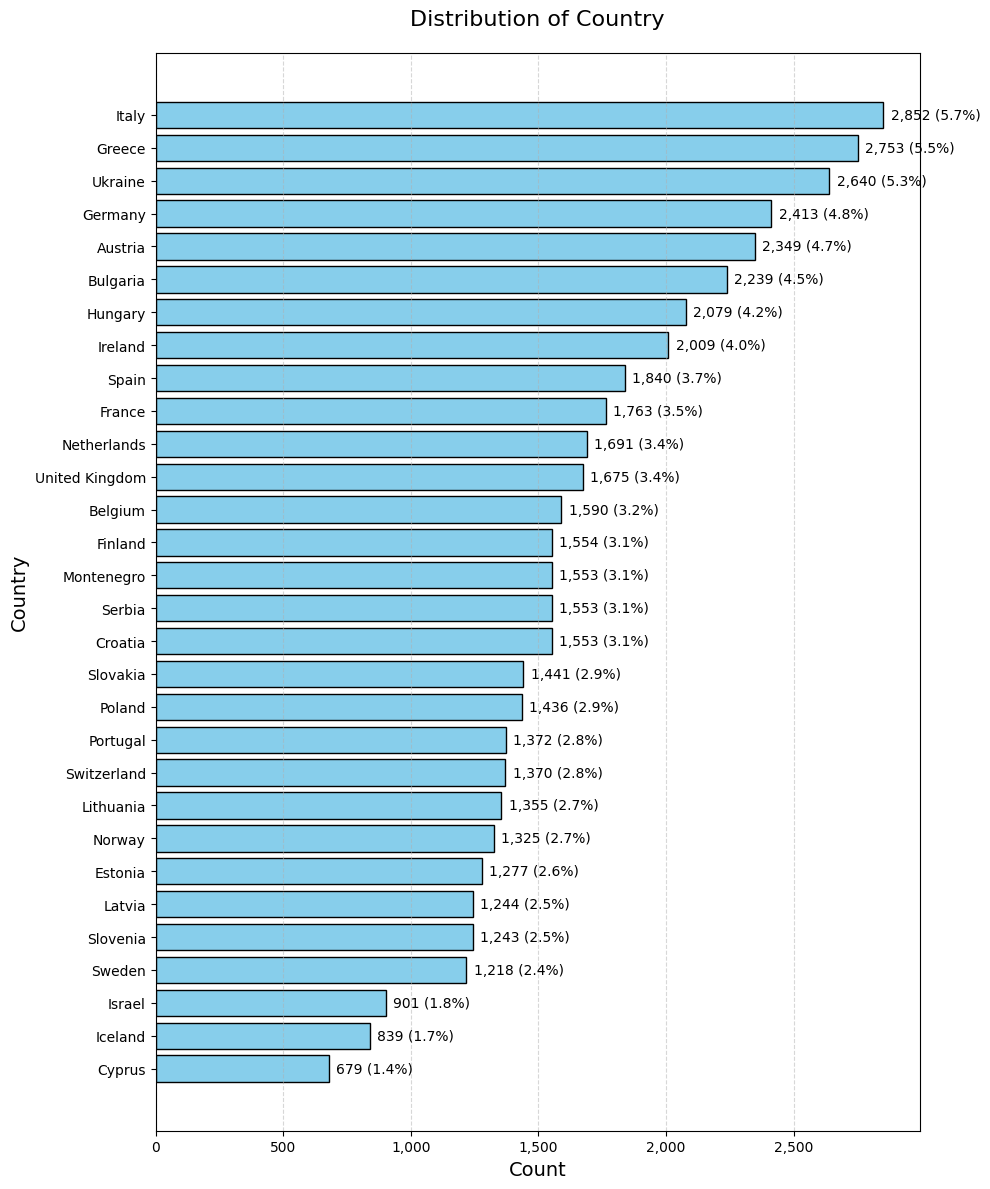

In [12]:


# List of country codes and labels
countries = [
    'AT','BE','BG','CH','CY','DE','EE','ES','FI','FR','GB','GR','HR',
    'HU','IE','IS','IL','IT','LT','LV','ME','NL','NO','PL','PT','RS',
    'SE','SI','SK','UA'
]

country_labels = [
    'Austria','Belgium','Bulgaria','Switzerland','Cyprus','Germany',
    'Estonia','Spain','Finland','France','United Kingdom','Greece','Croatia','Hungary',
    'Ireland','Iceland','Israel','Italy','Lithuania','Latvia','Montenegro','Netherlands',
    'Norway','Poland','Portugal','Serbia',
    'Sweden','Slovenia','Slovakia','Ukraine'
]

# Compute counts
class_counts = [np.sum(df_clean['country'] == c) for c in countries]
total = sum(class_counts)
class_percents = [(count / total) * 100 for count in class_counts]

# Sort from lowest to highest
sorted_idx = np.argsort(class_counts)
sorted_counts = [class_counts[i] for i in sorted_idx]
sorted_labels = [country_labels[i] for i in sorted_idx]
sorted_percents = [class_percents[i] for i in sorted_idx]

# Horizontal bar plot
plt.figure(figsize=(10, 12))
bars = plt.barh(sorted_labels, sorted_counts, color='skyblue', edgecolor='black')

plt.xlabel('Count', fontsize=14)
plt.ylabel('Country', fontsize=14)
plt.title('Distribution of Country', fontsize=16, pad=20)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)

# Add value labels with count and percentage
for bar, percent in zip(bars, sorted_percents):
    width = bar.get_width()
    plt.text(
        width + max(sorted_counts)*0.01,
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,} ({percent:.1f}%)",
        va='center',
        fontsize=10
    )

# Format x-axis with thousands separator
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
#plt.savefig('country_class_dist_horizontal.pdf', dpi=300)
plt.show()


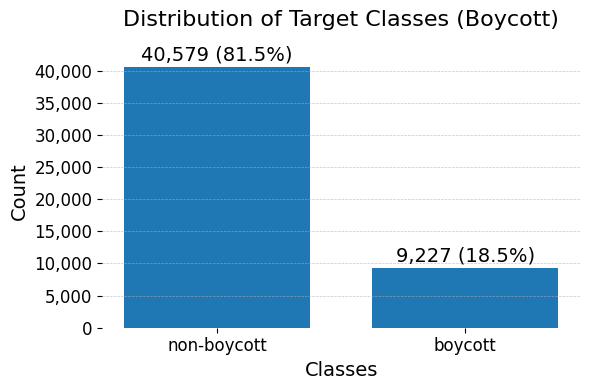

In [13]:
# Count samples in each class (bctprd = 1 or 2)
class_counts = [
    np.sum(df_clean['boycott'] == 0),
    np.sum(df_clean['boycott'] == 1)
]

class_labels = ['non-boycott', 'boycott']

# Calculate percentages
total = sum(class_counts)
class_percents = [(count / total) * 100 for count in class_counts]

# Bar Plot
plt.figure(figsize=(6, 4))
bars = plt.bar(class_labels, class_counts, width=0.75)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7, axis='y')

# Title and labels
plt.title('Distribution of Target Classes (Boycott)', fontsize=16, pad=20)  # space above bars
plt.xlabel('Classes', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add value labels above the bars with count and percentage
for bar, percent in zip(bars, class_percents):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + max(class_counts)*0.01,  # slightly above the bar
        f"{int(yval):,} ({percent:.1f}%)",  # count with thousands separator and %
        ha='center',
        va='bottom',
        fontsize=14
    )

# Format y-axis with thousands separator
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Remove spines
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
#plt.savefig('bctprd_class_dist.pdf', dpi=300)
plt.show()


In [14]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.


<Figure size 2000x600 with 0 Axes>

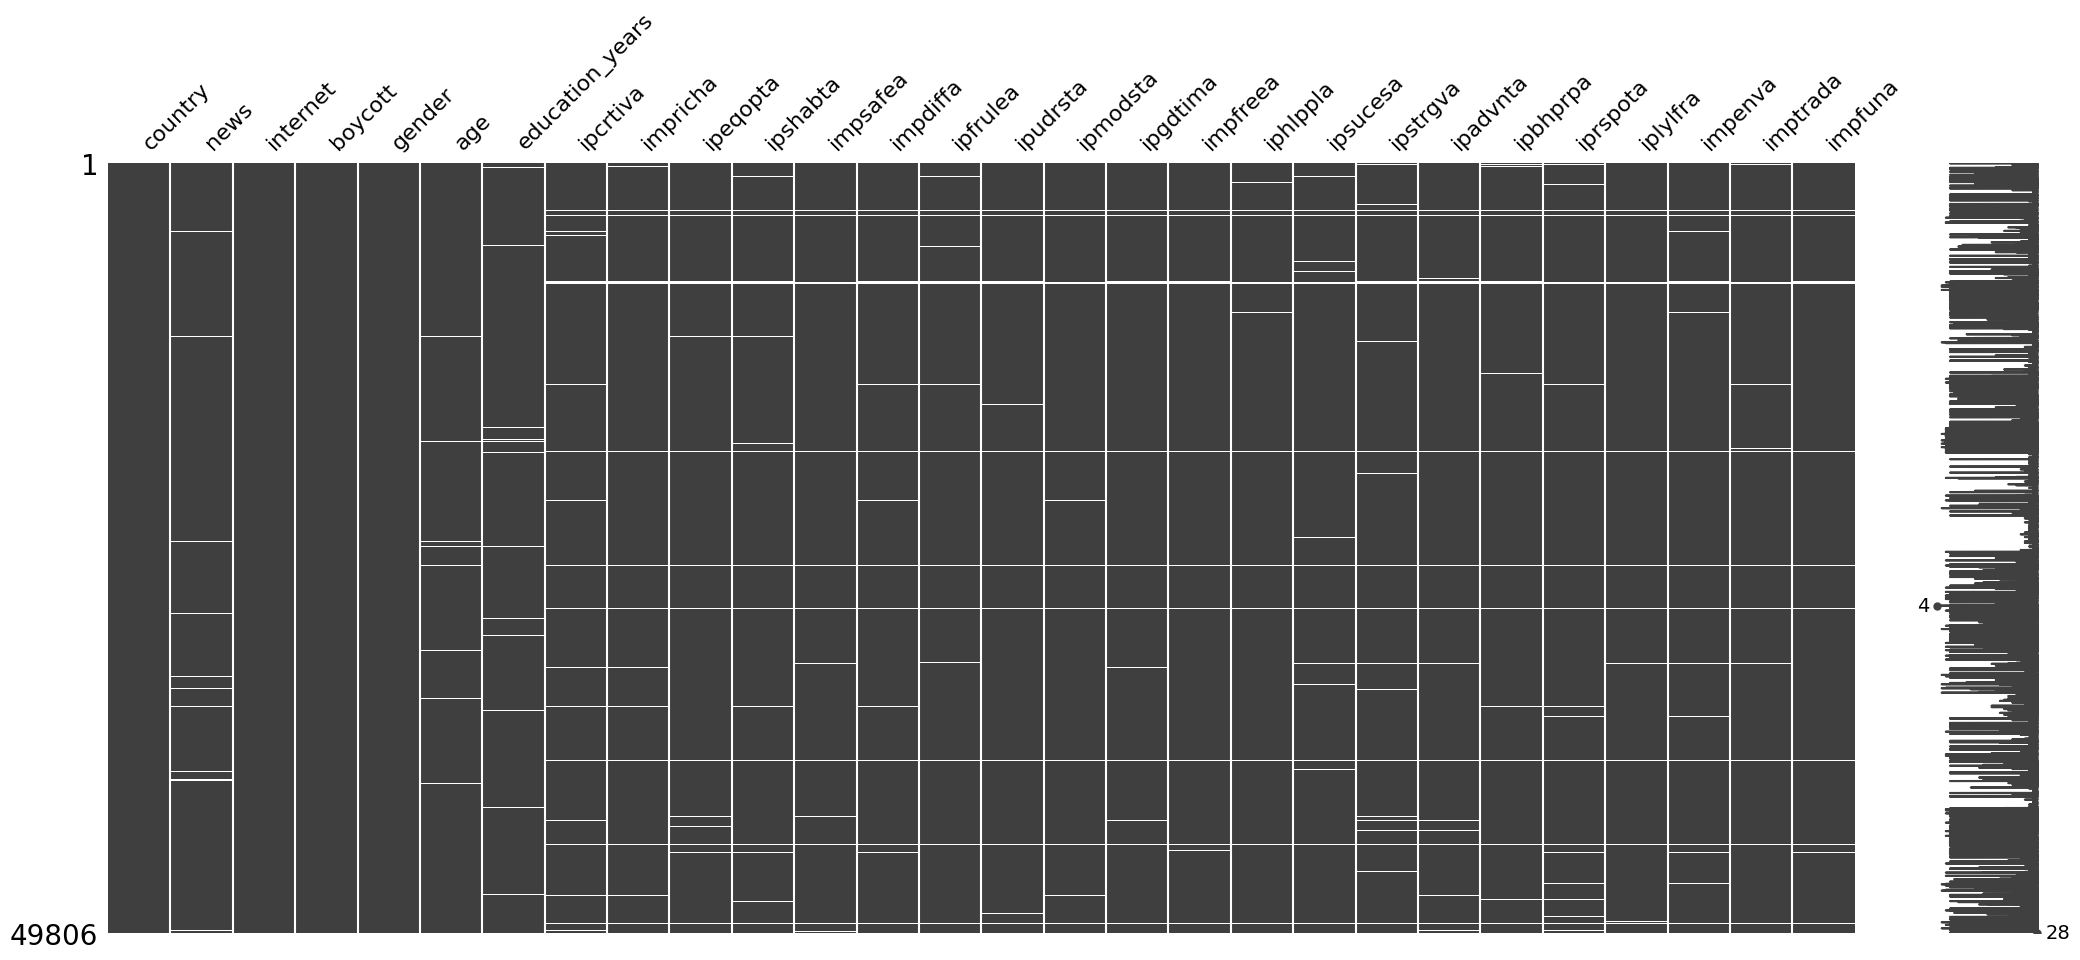

<Figure size 1200x1000 with 0 Axes>

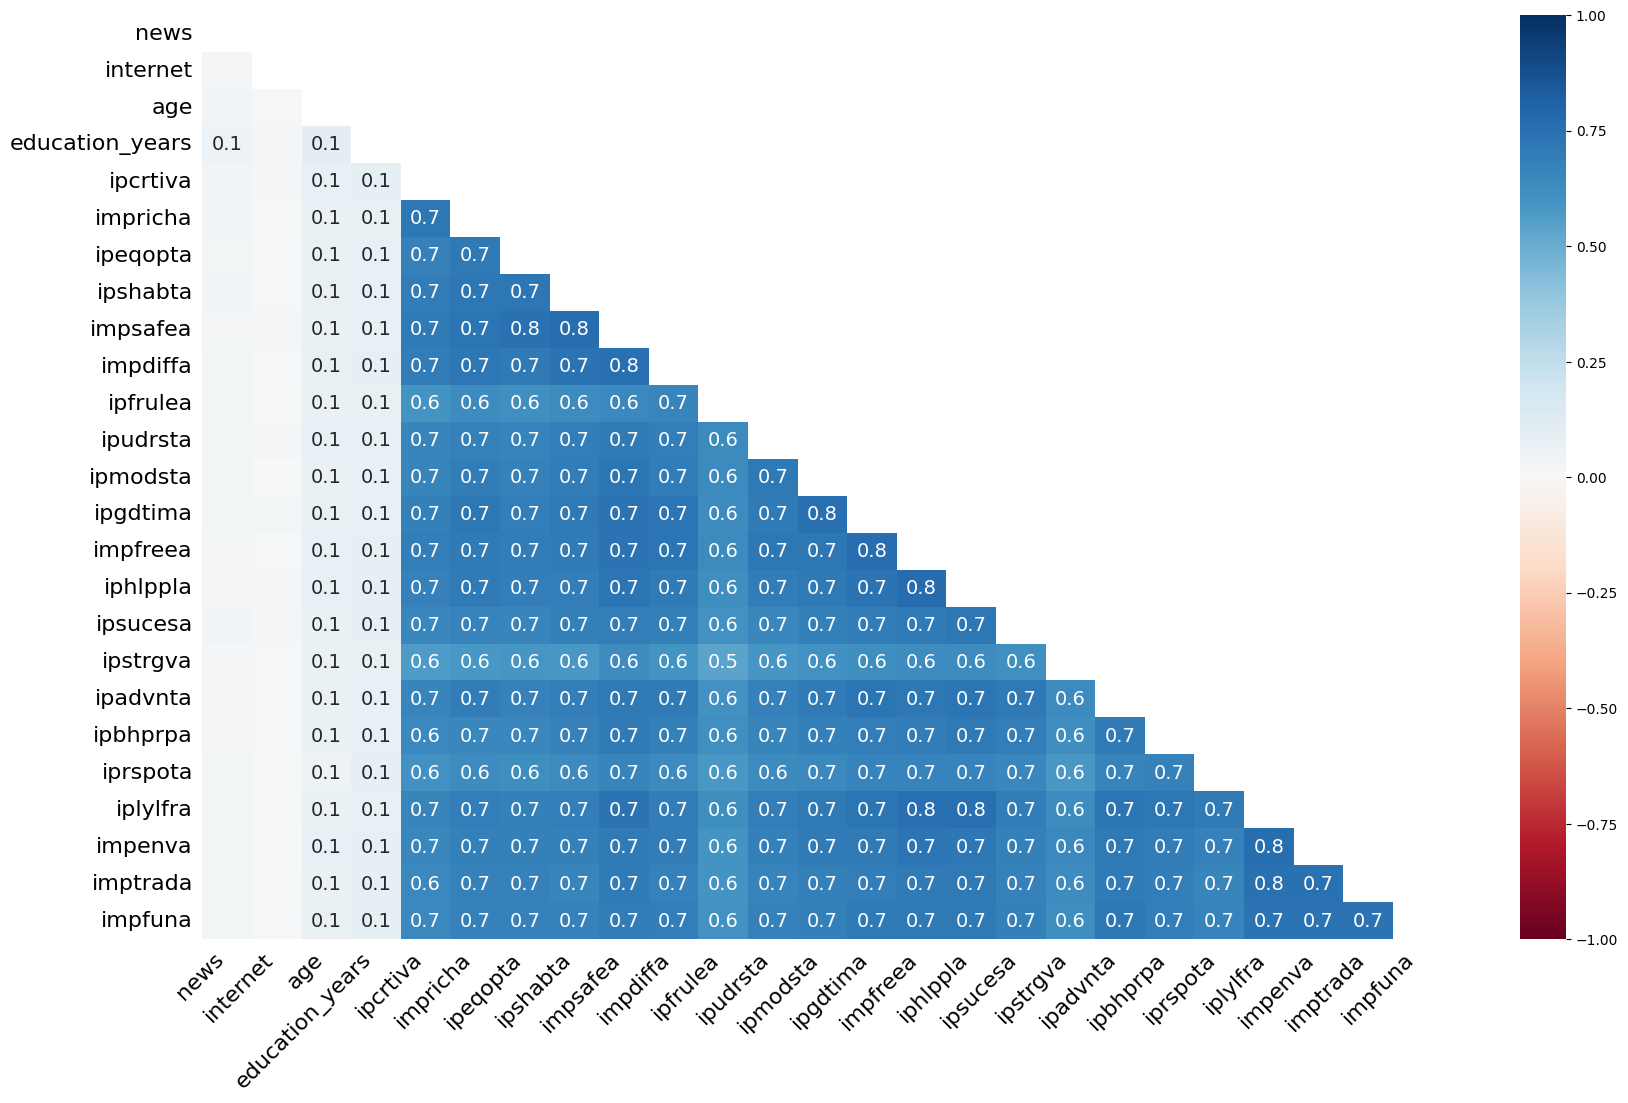

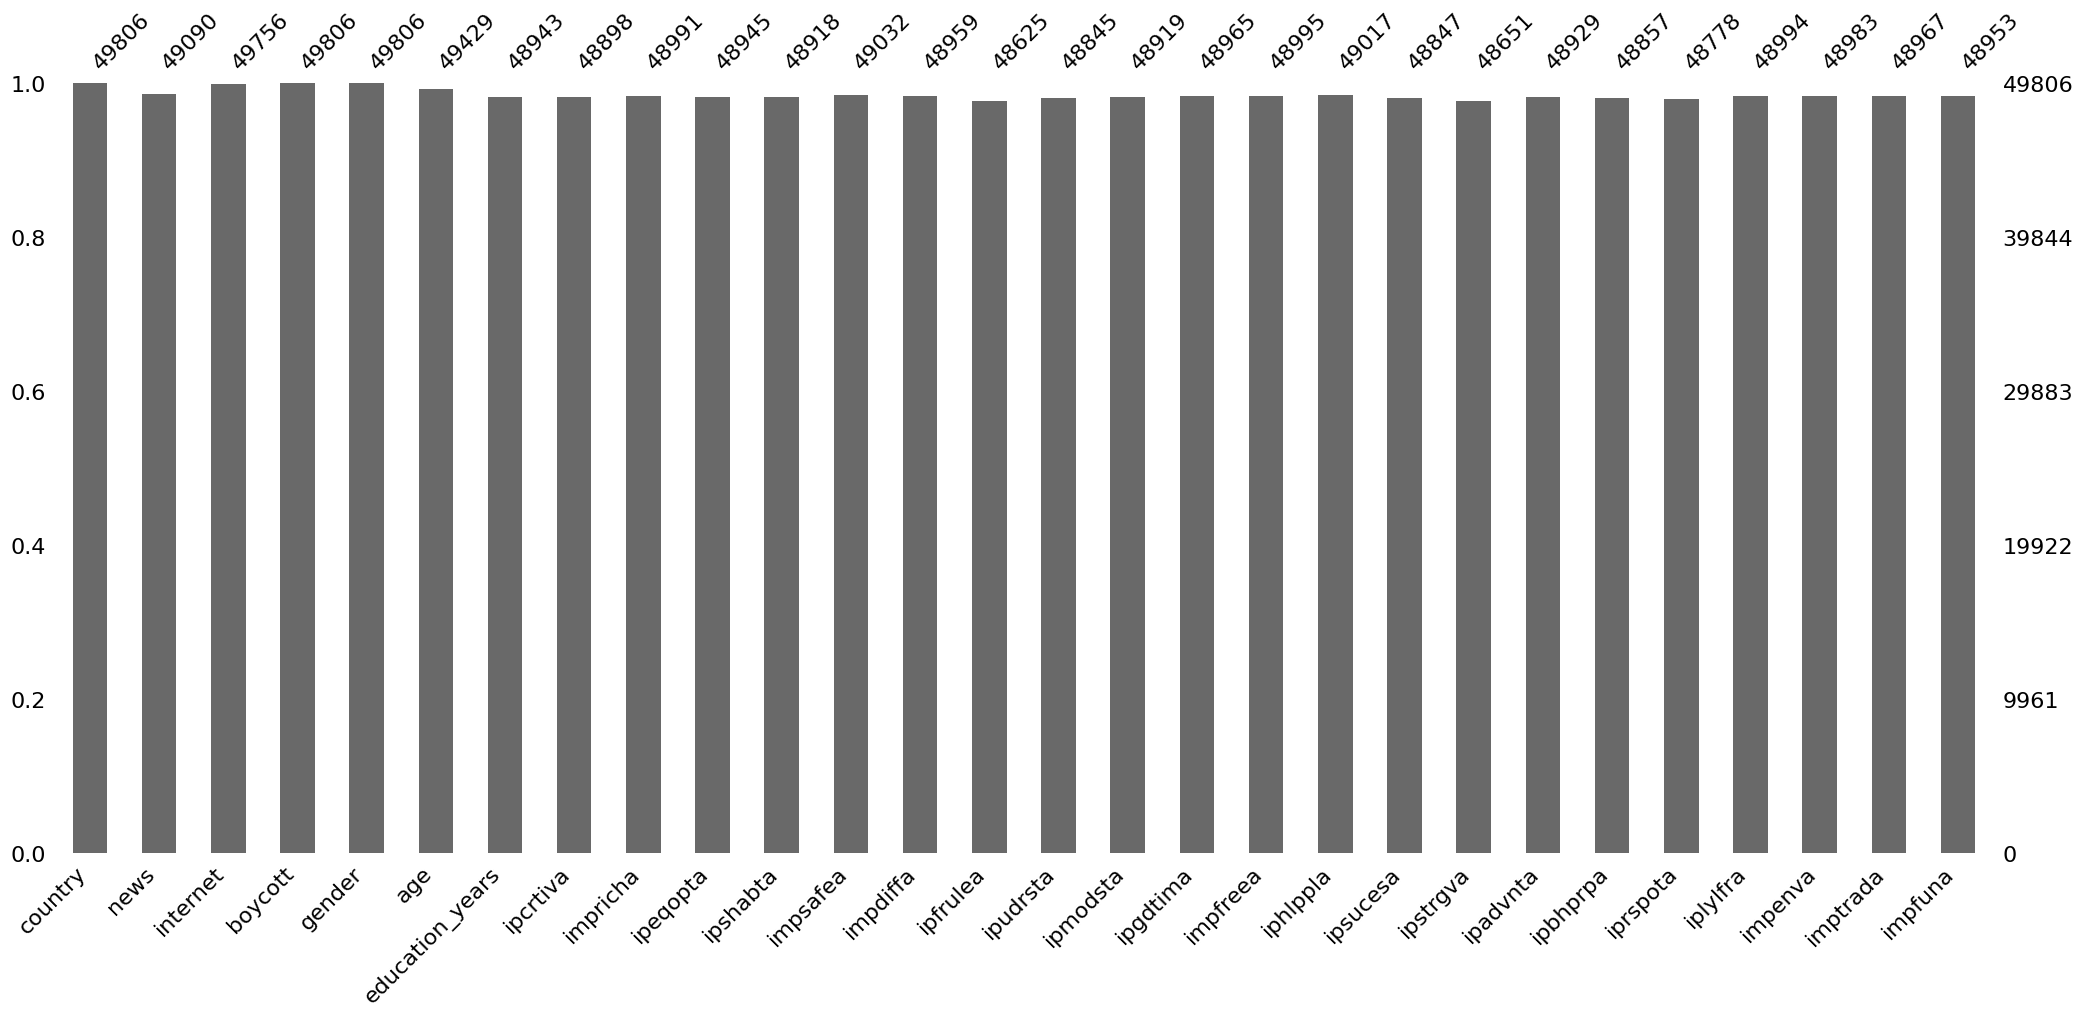

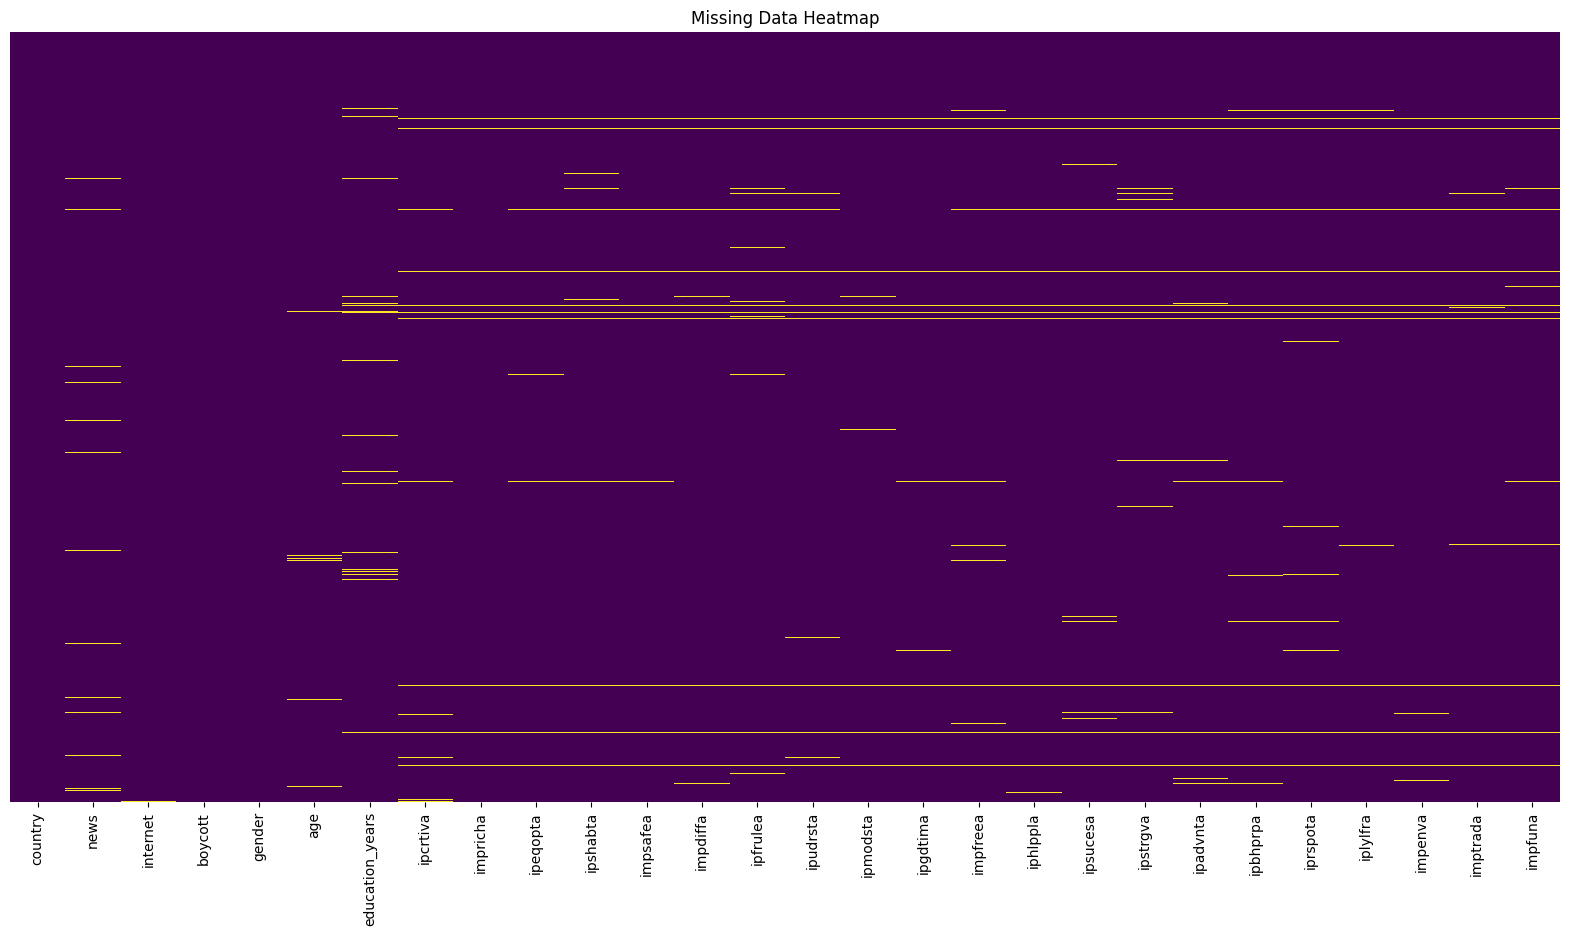

Missing values (%) per column:
ipfrulea           2.371200
ipstrgva           2.318998
iprspota           2.064008
ipudrsta           1.929486
ipsucesa           1.925471
ipbhprpa           1.905393
ipcrtiva           1.823074
ipshabta           1.782918
ipmodsta           1.780910
ipadvnta           1.760832
education_years    1.732723
ipeqopta           1.728707
impfuna            1.712645
impdiffa           1.700598
ipgdtima           1.688552
imptrada           1.684536
impenva            1.652411
impricha           1.636349
iplylfra           1.630326
impfreea           1.628318
iphlppla           1.584146
impsafea           1.554030
news               1.437578
age                0.756937
internet           0.100390
gender             0.000000
country            0.000000
boycott            0.000000
dtype: float64


In [15]:
#missing data pattern
import missingno as msno

# 8a. Missing data matrix
plt.figure(figsize=(20,6))
msno.matrix(df_clean)
plt.show()

# 8b. Missing data heatmap (shows correlation of missingness)
plt.figure(figsize=(12,10))
msno.heatmap(df_clean)
plt.show()

# 8c. Missing data bar chart (count per column)
plt.figure(figsize=(16,6))
msno.bar(df_clean)
plt.show()

# 8d. Optional: seaborn heatmap for full matrix view
plt.figure(figsize=(20,10))
sns.heatmap(df_clean.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

# 9️⃣ OPTIONAL: check missing percentage numerically
missing_percent = df_clean.isna().mean() * 100
missing_percent = missing_percent.sort_values(ascending=False)
print("Missing values (%) per column:")
print(missing_percent)




## 1.4 Preprocessing

In [16]:
#remove outlier
data = df_clean['news']

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

outlier_percentage = (
    ((data < (Q1 - 1.5*IQR)) | (data > (Q3 + 1.5*IQR))).sum()
    / len(data) * 100
)

print(outlier_percentage)


#calculate 99% percentile
upper_99 = df_clean['news'].quantile(0.99)
print("99th percentile (upper limit):", upper_99)

# remove outliers
df_clean = df_clean[df_clean['news'] <= upper_99]

# sense check max
max_value_after_clean = df_clean['news'].max()
remaining_samples = df_clean.shape[0]

print("Max value after removing extreme values:", max_value_after_clean)
print("Number of remaining samples:", remaining_samples)
print(outlier_percentage)

5.854716299241056
99th percentile (upper limit): 941.3300000000017
Max value after removing extreme values: 941.0
Number of remaining samples: 48599
5.854716299241056


In [17]:
before_rows = df_clean.shape[0]

# delete rows over 40% missing values
threshold = int(df_clean.shape[1] * 0.6)
df_clean = df_clean.dropna(thresh=threshold)

after_rows = df_clean.shape[0]
print("Rows before removal:", before_rows)
print("Rows after removal:", after_rows)
print("Rows removed:", before_rows - after_rows)

Rows before removal: 48599
Rows after removal: 48020
Rows removed: 579


In [18]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 48020 entries, 0 to 50115
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          48020 non-null  str    
 1   news             48020 non-null  float64
 2   internet         47977 non-null  float64
 3   boycott          48020 non-null  object 
 4   gender           48020 non-null  object 
 5   age              47701 non-null  float64
 6   education_years  47292 non-null  float64
 7   ipcrtiva         47703 non-null  float64
 8   impricha         47787 non-null  float64
 9   ipeqopta         47739 non-null  float64
 10  ipshabta         47728 non-null  float64
 11  impsafea         47829 non-null  float64
 12  impdiffa         47762 non-null  float64
 13  ipfrulea         47453 non-null  float64
 14  ipudrsta         47670 non-null  float64
 15  ipmodsta         47745 non-null  float64
 16  ipgdtima         47789 non-null  float64
 17  impfreea         47810 non-n

In [19]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 48020 entries, 0 to 50115
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          48020 non-null  str    
 1   news             48020 non-null  float64
 2   internet         47977 non-null  float64
 3   boycott          48020 non-null  object 
 4   gender           48020 non-null  object 
 5   age              47701 non-null  float64
 6   education_years  47292 non-null  float64
 7   ipcrtiva         47703 non-null  float64
 8   impricha         47787 non-null  float64
 9   ipeqopta         47739 non-null  float64
 10  ipshabta         47728 non-null  float64
 11  impsafea         47829 non-null  float64
 12  impdiffa         47762 non-null  float64
 13  ipfrulea         47453 non-null  float64
 14  ipudrsta         47670 non-null  float64
 15  ipmodsta         47745 non-null  float64
 16  ipgdtima         47789 non-null  float64
 17  impfreea         47810 non-n

In [20]:
df_clean.describe()

,news,internet,age,education_years,ipcrtiva,impricha,ipeqopta,ipshabta,impsafea,impdiffa,...,iphlppla,ipsucesa,ipstrgva,ipadvnta,ipbhprpa,iprspota,iplylfra,impenva,imptrada,impfuna
count,48020.000000,47977.000000,47701.000000,47292.000000,47703.000000,47787.000000,47739.000000,47728.000000,47829.000000,47762.000000,...,47819.000000,47681.000000,47466.000000,47749.000000,47679.000000,47613.000000,47802.000000,47786.000000,47771.000000,47763.000000
mean,88.078176,4.209455,51.638917,13.269644,2.617907,4.076046,2.043801,3.225318,2.256539,3.035886,...,2.190405,3.168579,2.243142,3.813064,2.633717,3.168609,1.968307,2.171117,2.709405,2.957038
std,127.151362,1.413080,18.604767,4.021168,1.289672,1.359482,1.072544,1.411892,1.194954,1.366847,...,1.020425,1.378260,1.166484,1.456293,1.248895,1.386924,0.977723,1.057693,1.364737,1.331004
min,0.000000,1.000000,15.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,30.000000,4.000000,37.000000,11.000000,2.000000,3.000000,1.000000,2.000000,1.000000,2.000000,...,1.000000,2.000000,1.000000,3.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000
50%,60.000000,5.000000,52.000000,13.000000,2.000000,4.000000,2.000000,3.000000,2.000000,3.000000,...,2.000000,3.000000,2.000000,4.000000,2.000000,3.000000,2.000000,2.000000,2.000000,3.000000
75%,105.000000,5.000000,67.000000,16.000000,3.000000,5.000000,3.000000,4.000000,3.000000,4.000000,...,3.000000,4.000000,3.000000,5.000000,3.000000,4.000000,2.000000,3.000000,4.000000,4.000000
max,941.000000,5.000000,90.000000,69.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,...,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000


In [21]:
pip install xgboost catboost

Note: you may need to restart the kernel to use updated packages.


In [22]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [24]:
conda install -c conda-forge llvm-openmp

2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: osx-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 25.7.0

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [25]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


## Logistic Regression, Random Forest, XG Boost

In [55]:
import numpy as np
import pandas as pd
from itertools import product

from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, average_precision_score, precision_score, recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# -----------------------------
# 1. DATA PREPARATION & WEIGHT ALIGNMENT
# -----------------------------
# Pull pspwght from original df using the index of df_clean to ensure alignment
weights = df.loc[df_clean.index, 'pspwght'].copy()

# Target and Features
y = df_clean['boycott'].astype(int)
X = df_clean.drop('boycott', axis=1)

numerical_cols = list(X.select_dtypes(include=['float64']).columns)
categorical_cols = list(X.select_dtypes(include=['object']).columns)

# -----------------------------
# 2. HOLDOUT SPLIT
# -----------------------------
# We split X, y, and weights simultaneously to maintain row-level integrity
X_trainval, X_holdout, y_trainval, y_holdout, weights_trainval, weights_holdout = train_test_split(
    X, y, weights,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# -----------------------------
# 3. NESTED CV FUNCTION
# -----------------------------
def run_nested_cv(X, y, weights_series, numerical_cols, categorical_cols, use_class_weight=False):

    random_state = 42
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    label = "WEIGHTED (CLASS + PSPWGHT)" if use_class_weight else "PSPWGHT ONLY"
    print(f"\n{'='*50}\nSTARTING NESTED CV: {label}\n{'='*50}")

    results = {}

    # Outer Loop: Generalization Performance
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
        print(f"\n[Outer Fold {fold}/5]")

        X_train_full = X.iloc[train_idx]
        X_test       = X.iloc[test_idx]
        y_train_full = y.iloc[train_idx]
        y_test       = y.iloc[test_idx]
        w_train_full = weights_series.iloc[train_idx] # Extract weights for this fold

        # Fold-specific class ratio for XGBoost
        scale_factor = (y_train_full == 0).sum() / (y_train_full == 1).sum()

        # Preprocessors
        def make_preprocessor_scaled():
            return ColumnTransformer([
                ('num', Pipeline([
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler())
                ]), numerical_cols),
                ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
            ])

        def make_preprocessor_standard():
            return ColumnTransformer([
                ('num', SimpleImputer(strategy='median'), numerical_cols),
                ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
            ])

        # Model Definitions
        model_specs = {
            "Logistic Regression": {
                "pipeline": Pipeline([
                    ("preprocessor", make_preprocessor_scaled()),
                    ("model", LogisticRegression(
                        max_iter=2000, solver='liblinear',
                        class_weight='balanced' if use_class_weight else None,
                        random_state=random_state
                    ))
                ]),
                "params": {"model__C": [0.1, 1.0, 10.0]}
            },
            "Random Forest": {
                "pipeline": Pipeline([
                    ("preprocessor", make_preprocessor_standard()),
                    ("model", RandomForestClassifier(
                        random_state=random_state,
                        class_weight='balanced' if use_class_weight else None
                    ))
                ]),
                "params": {
                    "model__n_estimators": [50, 100, 200],
                    "model__max_depth": [3, 5, 10]
                }
            },
            "XGBoost": {
                "pipeline": Pipeline([
                    ("preprocessor", make_preprocessor_standard()),
                    ("model", XGBClassifier(
                        eval_metric='logloss',
                        random_state=random_state,
                        scale_pos_weight=scale_factor if use_class_weight else 1,
                        verbosity=0
                    ))
                ]),
                "params": {
                    "model__max_depth": [3, 6, 8],
                    "model__learning_rate": [0.05, 0.1, 0.3]
                }
            }
        }

        # Inner Loop: Hyperparameter Tuning
        for name, spec in model_specs.items():
            grid_search = GridSearchCV(
                estimator=spec["pipeline"],
                param_grid=spec["params"],
                cv=inner_cv,
                scoring='f1',
                n_jobs=-1,
                refit=True
            )

            # Fit passing the pspwght to the model step of the pipeline
            grid_search.fit(X_train_full, y_train_full, model__sample_weight=w_train_full)

            best_model = grid_search.best_estimator_
            print(f"  {name} | Best: {grid_search.best_params_} | Inner F1: {grid_search.best_score_:.4f}")

            # Outer Evaluation
            y_pred = best_model.predict(X_test)
            y_prob = best_model.predict_proba(X_test)[:, 1]

            if name not in results:
                results[name] = {
                    'test_f1': [], 'test_average_precision': [],
                    'test_precision': [], 'test_recall': []
                }

            results[name]['test_f1'].append(f1_score(y_test, y_pred))
            results[name]['test_average_precision'].append(average_precision_score(y_test, y_prob))
            results[name]['test_precision'].append(precision_score(y_test, y_pred, zero_division=0))
            results[name]['test_recall'].append(recall_score(y_test, y_pred))

    return results

# -----------------------------
# 4. EXECUTION & SUMMARY
# -----------------------------
res_weighted   = run_nested_cv(X_trainval, y_trainval, weights_trainval, numerical_cols, categorical_cols, use_class_weight=True)
res_unweighted = run_nested_cv(X_trainval, y_trainval, weights_trainval, numerical_cols, categorical_cols, use_class_weight=False)

def print_nested_cv_summary(results, label):
    print("\n" + "="*55)
    print(f"   SUMMARY RESULTS: {label}")
    print("="*55)
    for model_name, metrics in results.items():
        print(f"\nMODEL: {model_name}\n{'-'*45}")
        print(f"{'Metric':<20} | {'Mean':<8} ± {'Std Dev':<8}\n{'-'*45}")
        
        metrics_to_report = [
            ("F1-Score", 'test_f1'),
            ("PR-AUC",   'test_average_precision'),
            ("Precision",'test_precision'),
            ("Recall",   'test_recall')
        ]
        
        for display_name, key in metrics_to_report:
            values = metrics[key]
            print(f"{display_name:<20} | {np.mean(values):.4f}  ± {np.std(values):.4f}")
    print("="*55)

print_nested_cv_summary(res_weighted, "WEIGHTED")
print_nested_cv_summary(res_unweighted, "UNWEIGHTED")

/var/folders/p5/dd0mn9h16750wt2b1yj0qkf80000gn/T/ipykernel_95273/553214043.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = list(X.select_dtypes(include=['object']).columns)



STARTING NESTED CV: WEIGHTED (CLASS + PSPWGHT)

[Outer Fold 1/5]
  Logistic Regression | Best: {'model__C': 1.0} | Inner F1: 0.4726
  Random Forest | Best: {'model__max_depth': 10, 'model__n_estimators': 200} | Inner F1: 0.4728
  XGBoost | Best: {'model__learning_rate': 0.1, 'model__max_depth': 6} | Inner F1: 0.4923

[Outer Fold 2/5]
  Logistic Regression | Best: {'model__C': 0.1} | Inner F1: 0.4773
  Random Forest | Best: {'model__max_depth': 10, 'model__n_estimators': 50} | Inner F1: 0.4760
  XGBoost | Best: {'model__learning_rate': 0.1, 'model__max_depth': 6} | Inner F1: 0.4968

[Outer Fold 3/5]
  Logistic Regression | Best: {'model__C': 0.1} | Inner F1: 0.4830
  Random Forest | Best: {'model__max_depth': 10, 'model__n_estimators': 100} | Inner F1: 0.4790
  XGBoost | Best: {'model__learning_rate': 0.1, 'model__max_depth': 6} | Inner F1: 0.4960

[Outer Fold 4/5]
  Logistic Regression | Best: {'model__C': 0.1} | Inner F1: 0.4754
  Random Forest | Best: {'model__max_depth': 10, 'model

## Cat

In [65]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, average_precision_score, precision_score, recall_score
from catboost import CatBoostClassifier

# -----------------------------
# WEIGHTING UTILITY
# -----------------------------
def balanced_weights(y):
    """
    Computes weights to balance classes.
    Returns a list of plain floats to avoid Scikit-Learn cloning errors.
    """
    n = len(y)
    w0 = n / (2 * (y == 0).sum())
    w1 = n / (2 * (y == 1).sum())
    return [float(w0), float(w1)]

# -----------------------------
# CATBOOST NESTED CV FUNCTION
# -----------------------------
def run_catboost_nested_cv(X, y, weights_series, numerical_cols, categorical_cols, use_class_weight=False):

    random_state = 42
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    label = "WEIGHTED (CLASS + PSPWGHT)" if use_class_weight else "PSPWGHT ONLY"
    print(f"\n{'='*50}\nSTARTING CATBOOST NESTED CV: {label}\n{'='*50}")

    results = {'CatBoost': {
        'test_f1': [],
        'test_average_precision': [],
        'test_precision': [],
        'test_recall': []
    }}

    # Preprocessor
    preprocessor = ColumnTransformer([
        ('num', SimpleImputer(strategy='median'), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
        print(f"\n[Outer Fold {fold}/5]")

        X_train_full = X.iloc[train_idx]
        X_test       = X.iloc[test_idx]
        y_train_full = y.iloc[train_idx]
        y_test       = y.iloc[test_idx]
        w_train_full = weights_series.iloc[train_idx] # Pull pspwght for this fold

        # Define basic pipeline
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", CatBoostClassifier(
                logging_level='Silent',
                random_state=random_state,
                allow_writing_files=False,
                thread_count=1  
            ))
        ])

        # Hyperparameter Grid
        param_grid = {
            "model__depth":          [4, 6, 8],
            "model__learning_rate":  [0.01, 0.03, 0.1],
        }

        # Conditionally add class weights
        if use_class_weight:
            current_weights = balanced_weights(y_train_full)
            param_grid["model__class_weights"] = [current_weights]

        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            cv=inner_cv,
            scoring='f1',
            n_jobs=-1,
            refit=True
        )

        # Pass pspwght to the model step during fit
        grid_search.fit(X_train_full, y_train_full, model__sample_weight=w_train_full)
        
        best_model = grid_search.best_estimator_

        # Clean display for params
        display_params = grid_search.best_params_.copy()
        display_params.pop('model__class_weights', None)
        print(f"  CatBoost | Best: {display_params} | Inner F1: {grid_search.best_score_:.4f}")

        # -----------------------------
        # OUTER EVALUATION
        # -----------------------------
        y_pred = best_model.predict(X_test)
        y_prob = best_model.predict_proba(X_test)[:, 1]

        y_pred = np.array(y_pred).astype(int).flatten()

        results['CatBoost']['test_f1'].append(f1_score(y_test, y_pred))
        results['CatBoost']['test_average_precision'].append(average_precision_score(y_test, y_prob))
        results['CatBoost']['test_precision'].append(precision_score(y_test, y_pred, zero_division=0))
        results['CatBoost']['test_recall'].append(recall_score(y_test, y_pred))

    return results

# -----------------------------
# RUN
# -----------------------------
res_cat_weighted   = run_catboost_nested_cv(X_trainval, y_trainval, weights_trainval, numerical_cols, categorical_cols, use_class_weight=True)
res_cat_unweighted = run_catboost_nested_cv(X_trainval, y_trainval, weights_trainval, numerical_cols, categorical_cols, use_class_weight=False)

# (print_catboost_summary function remains the same as your provided version)


# -----------------------------
# DETAILED CATBOOST SUMMARY
# -----------------------------
def print_catboost_summary(results, label):
    print("\n" + "="*45)
    print(f"   CATBOOST FINAL RESULTS: {label}")
    print("="*45)
    print(f"{'METRIC':<15} | {'MEAN':<8} ± {'STD DEV':<8}")
    print("-" * 45)
    
    # metrics available in your results['CatBoost'] dictionary
    metrics_map = [
        ("F1-Score",  'test_f1'),
        ("PR-AUC",    'test_average_precision'), # AP is the PR-AUC equivalent here
        ("Precision", 'test_precision'),
        ("Recall",    'test_recall')
    ]

    for name, key in metrics_map:
        values = results['CatBoost'][key]
        mean_val = np.mean(values)
        std_val  = np.std(values)
        print(f"{name:<15} | {mean_val:.4f}  ± {std_val:.4f}")
    print("="*45)

# Run summary for both
print_catboost_summary(res_cat_weighted, "WEIGHTED")
print_catboost_summary(res_cat_unweighted, "UNWEIGHTED")


STARTING CATBOOST NESTED CV: WEIGHTED (CLASS + PSPWGHT)

[Outer Fold 1/5]
  CatBoost | Best: {'model__depth': 6, 'model__learning_rate': 0.03} | Inner F1: 0.5004

[Outer Fold 2/5]
  CatBoost | Best: {'model__depth': 8, 'model__learning_rate': 0.03} | Inner F1: 0.5101

[Outer Fold 3/5]
  CatBoost | Best: {'model__depth': 6, 'model__learning_rate': 0.03} | Inner F1: 0.5022

[Outer Fold 4/5]
  CatBoost | Best: {'model__depth': 6, 'model__learning_rate': 0.03} | Inner F1: 0.5004

[Outer Fold 5/5]
  CatBoost | Best: {'model__depth': 8, 'model__learning_rate': 0.03} | Inner F1: 0.5051

STARTING CATBOOST NESTED CV: PSPWGHT ONLY

[Outer Fold 1/5]
  CatBoost | Best: {'model__depth': 4, 'model__learning_rate': 0.1} | Inner F1: 0.3917

[Outer Fold 2/5]
  CatBoost | Best: {'model__depth': 4, 'model__learning_rate': 0.1} | Inner F1: 0.3935

[Outer Fold 3/5]
  CatBoost | Best: {'model__depth': 4, 'model__learning_rate': 0.1} | Inner F1: 0.4006

[Outer Fold 4/5]
  CatBoost | Best: {'model__depth': 6

## Random Classifier

In [56]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, precision_recall_curve, auc, precision_score, recall_score
from sklearn.impute import SimpleImputer


# -----------------------------
# RANDOM CLASSIFIER NESTED CV (With pspwght)
# -----------------------------
def run_random_classifier_nested_cv(X, y, weights_series, numerical_cols, categorical_cols):
    random_state = 42
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    print(f"\n{'='*50}\nSTARTING RANDOM CLASSIFIER NESTED CV (Weighted)\n{'='*50}")

    results = {'test_f1': [], 'test_pr_auc': [], 'test_precision': [], 'test_recall': []}

    preprocessor = ColumnTransformer([
        ('num', SimpleImputer(strategy='median'), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        w_train = weights_series.iloc[train_idx] # Pull the weights

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", DummyClassifier(random_state=random_state))
        ])

        param_grid = {"model__strategy": ["stratified", "most_frequent"]}

        grid_search = GridSearchCV(
            pipeline, 
            param_grid=param_grid, 
            cv=inner_cv, 
            scoring='f1', 
            n_jobs=-1
        )
        
        # --- KEY CHANGE: Pass weights here ---
        grid_search.fit(X_train, y_train, model__sample_weight=w_train)
        
        best_model = grid_search.best_estimator_

        y_prob = best_model.predict_proba(X_test)[:, 1]
        y_pred = best_model.predict(X_test)

        p_pts, r_pts, _ = precision_recall_curve(y_test, y_prob)
        pr_auc_score = auc(r_pts, p_pts)

        results['test_f1'].append(f1_score(y_test, y_pred, zero_division=0))
        results['test_precision'].append(precision_score(y_test, y_pred, zero_division=0))
        results['test_recall'].append(recall_score(y_test, y_pred, zero_division=0))
        results['test_pr_auc'].append(pr_auc_score)

        print(f"[Fold {fold}/5] Selected Strategy: {grid_search.best_params_['model__strategy']} | F1: {results['test_f1'][-1]:.4f}")

    return results

# EXECUTION
res_random = run_random_classifier_nested_cv(X_trainval, y_trainval, weights_trainval, numerical_cols, categorical_cols)

# -----------------------------
# FINAL SUMMARY WITH +/- (STD DEV)
# -----------------------------
print("\n" + "="*45)
print(f"{'METRIC':<15} | {'MEAN':<8} ± {'STD DEV':<8}")
print("="*45)

metrics_to_print = [
    ("F1-Score",  res_random['test_f1']),
    ("PR-AUC",    res_random['test_pr_auc']),
    ("Precision", res_random['test_precision']),
    ("Recall",    res_random['test_recall'])
]

for name, values in metrics_to_print:
    mean_val = np.mean(values)
    std_val  = np.std(values)
    print(f"{name:<15} | {mean_val:.4f}  ± {std_val:.4f}")

print("="*45)


STARTING RANDOM CLASSIFIER NESTED CV (Weighted)
[Fold 1/5] Selected Strategy: stratified | F1: 0.1967
[Fold 2/5] Selected Strategy: stratified | F1: 0.1784
[Fold 3/5] Selected Strategy: stratified | F1: 0.1796
[Fold 4/5] Selected Strategy: stratified | F1: 0.1820
[Fold 5/5] Selected Strategy: stratified | F1: 0.1708

METRIC          | MEAN     ± STD DEV 
F1-Score        | 0.1815  ± 0.0085
PR-AUC          | 0.2577  ± 0.0077
Precision       | 0.1830  ± 0.0087
Recall          | 0.1800  ± 0.0082


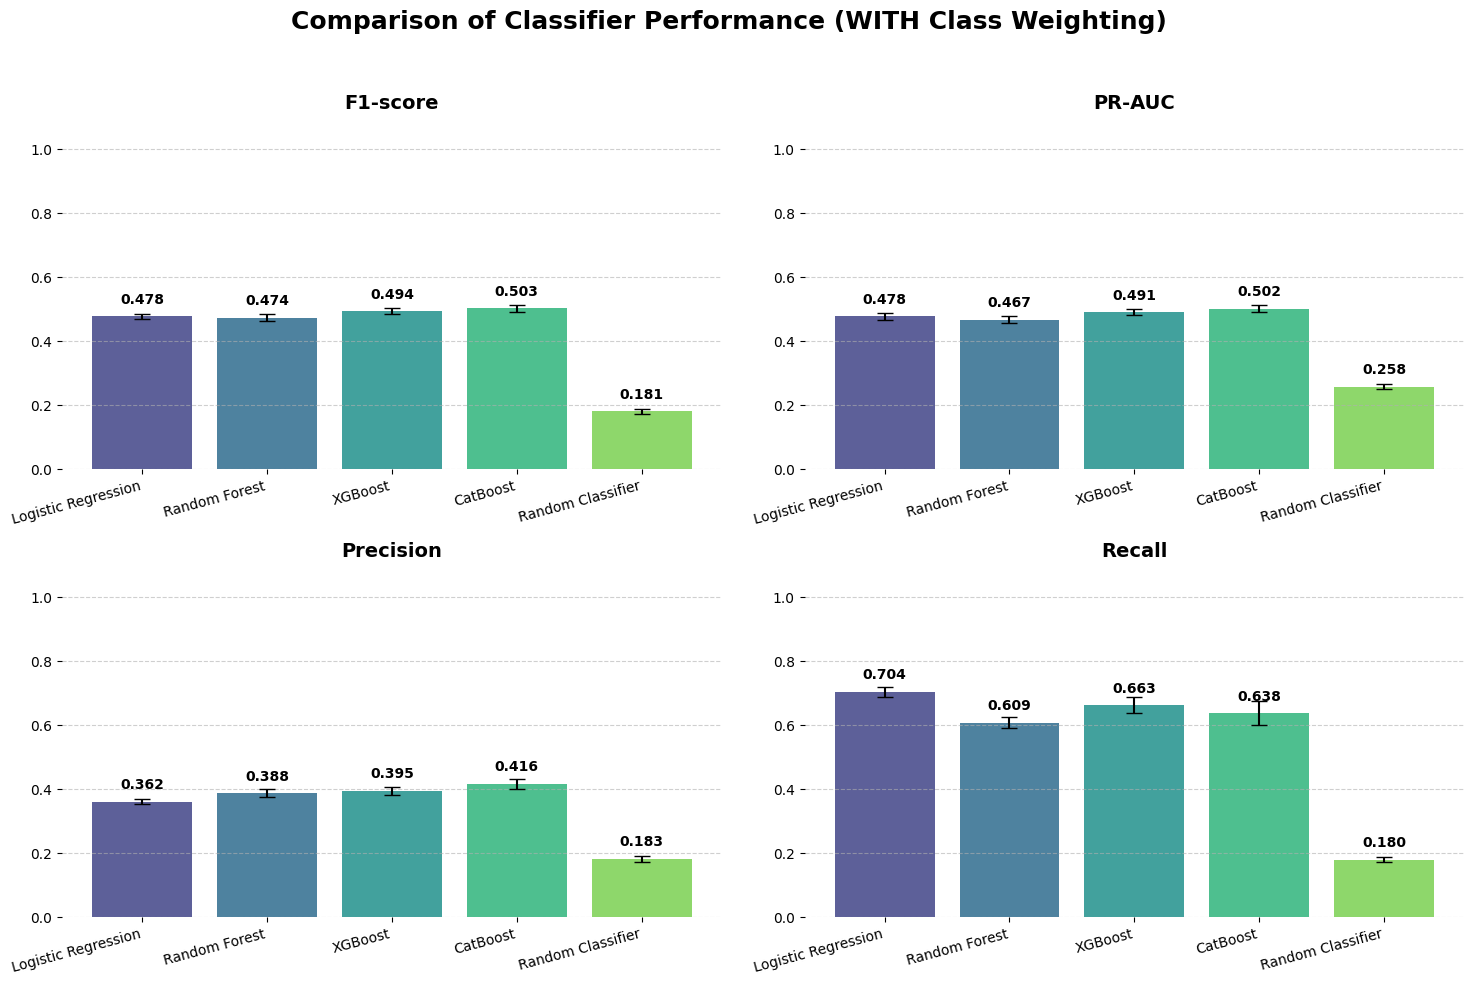

In [67]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. STANDARDIZE & MERGE
# -----------------------------
# res_weighted already has 'Logistic Regression', 'Random Forest', 'XGBoost'
# res_cat_weighted has 'CatBoost'

# FIX: Wrap res_random in its own key if it isn't already
# If res_random is already {'Random': {...}}, just use res_random
formatted_random = {"Random Classifier": res_random} if 'test_f1' in res_random else res_random

# Merge everything
current_results = {**res_weighted, **res_cat_weighted, **formatted_random}

# -----------------------------
# 2. MATCH METRIC KEYS
# -----------------------------
# Check your dictionaries! 
# Your Sklearn/CatBoost code used 'test_average_precision'
# Your Random code used 'test_pr_auc'
# We must map them correctly for the plot to work.

models_to_plot = list(current_results.keys())

def get_metric_safe(model_dict, key):
    """Helper to handle different key names like 'test_pr_auc' vs 'test_average_precision'"""
    if key == 'test_average_precision' and 'test_pr_auc' in model_dict:
        return model_dict['test_pr_auc']
    return model_dict.get(key, [0]) # Default to [0] if key is missing

metrics_map = {
    'F1-score': 'test_f1',
    'PR-AUC': 'test_average_precision', 
    'Precision': 'test_precision',
    'Recall': 'test_recall'
}

# -----------------------------
# 3. COMPUTE MEANS & STDS
# -----------------------------
means = {}
stds = {}

for m_name, m_key in metrics_map.items():
    means[m_name] = [np.mean(get_metric_safe(current_results[model], m_key)) for model in models_to_plot]
    stds[m_name] = [np.std(get_metric_safe(current_results[model], m_key)) for model in models_to_plot]

# -----------------------------
# 4. PLOT
# -----------------------------
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(models_to_plot)))
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, (metric_label, _) in enumerate(metrics_map.items()):
    ax = axes[i]
    # Use the model names for x-axis
    x_pos = np.arange(len(models_to_plot))
    
    bars = ax.bar(x_pos, means[metric_label], yerr=stds[metric_label], 
                  capsize=6, color=colors, alpha=0.85)
    
    ax.set_title(metric_label, fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(models_to_plot, rotation=15, ha='right')
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    for spine in ax.spines.values(): 
        spine.set_visible(False)
    
    for bar, mean in zip(bars, means[metric_label]):
        ax.text(bar.get_x() + bar.get_width() / 2, mean + 0.03, f"{mean:.3f}", 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

fig.suptitle('Comparison of Classifier Performance (WITH Class Weighting)', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Fit on full training set - Best Model


   FINAL HOLDOUT RESULTS (REPRESENTATIVE WEIGHTS)
F1-Score:  0.4847
Precision: 0.4146
Recall:    0.5833
PR-AUC:    0.4985
----------------------------------------

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.81      0.85 7813.240341020007
           1       0.41      0.58      0.48 1775.6320117499997

    accuracy                           0.77 9588.872352770006
   macro avg       0.66      0.70      0.67 9588.872352770006
weighted avg       0.81      0.77      0.78 9588.872352770006



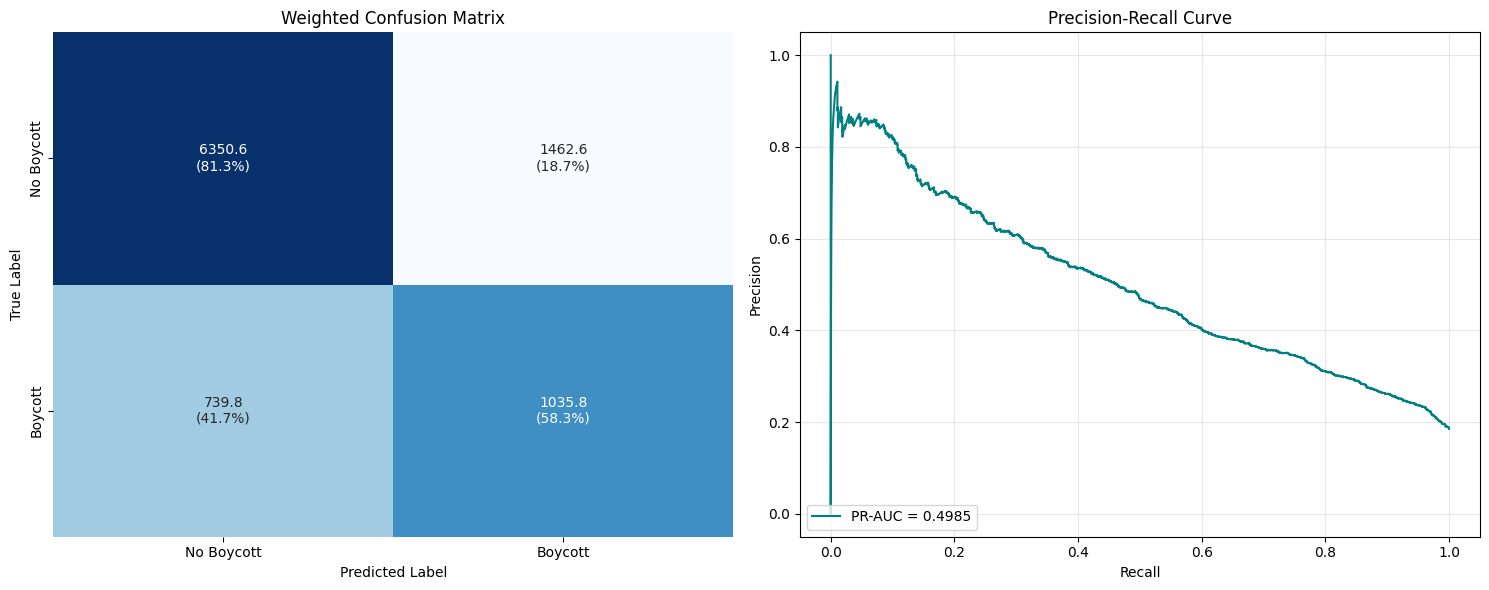

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# -----------------------------
# 1. SETUP CHAMPION MODEL
# -----------------------------
best_params = {
    'depth': 8,
    'learning_rate': 0.03
}

# Keep your class weights logic
w0, w1 = balanced_weights(y_trainval)
final_weights = [float(w0), float(w1)]

final_pipeline = Pipeline([
    ("preprocessor", ColumnTransformer([
        ('num', SimpleImputer(strategy='median'), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])),
    ("model", CatBoostClassifier(
        **best_params,
        class_weights=final_weights,
        logging_level='Silent',
        random_state=42,
        allow_writing_files=False,
        thread_count=-1
    ))
])

# -----------------------------
# 2. TRAIN & PREDICT
# -----------------------------
# KEY UPDATE: Pass weights_trainval to the fit method
final_pipeline.fit(X_trainval, y_trainval, model__sample_weight=weights_trainval)

y_holdout_pred = final_pipeline.predict(X_holdout).astype(int).flatten()
y_holdout_prob = final_pipeline.predict_proba(X_holdout)[:, 1]

# -----------------------------
# 3. CALCULATE METRICS (Weighted for Population Representativeness)
# -----------------------------
# Using sample_weight here makes your final metrics "Population Representative"
f1   = f1_score(y_holdout, y_holdout_pred, sample_weight=weights_holdout)
prec = precision_score(y_holdout, y_holdout_pred, sample_weight=weights_holdout)
rec  = recall_score(y_holdout, y_holdout_pred, sample_weight=weights_holdout)

# PR-AUC / average_precision_score with weights
ap_score = average_precision_score(y_holdout, y_holdout_prob, sample_weight=weights_holdout)

# Note: precision_recall_curve also accepts sample_weight for the plot
precision_pts, recall_pts, _ = precision_recall_curve(y_holdout, y_holdout_prob, sample_weight=weights_holdout)

# -----------------------------
# 4. PRINT RESULTS
# -----------------------------
print(f"\n{'='*40}")
print("   FINAL HOLDOUT RESULTS (REPRESENTATIVE WEIGHTS)")
print(f"{'='*40}")
print(f"F1-Score:  {f1:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"PR-AUC:    {ap_score:.4f}")
print(f"{'-'*40}")
# Use weights in classification report too
print("\nClassification Report:")
print(classification_report(y_holdout, y_holdout_pred, sample_weight=weights_holdout))

# -----------------------------
# 5. VISUALIZATION (Confusion Matrix with Weights)
# -----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# KEY UPDATE: Use weights in the confusion matrix calculation
cm = confusion_matrix(y_holdout, y_holdout_pred, sample_weight=weights_holdout)
cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100  

annot = np.array([
    [f"{cm[i,j]:.1f}\n({cm_percent[i,j]:.1f}%)" for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])
# Note: Since the CM is now weighted, counts will be decimals (total pop units), 
# which is why we use :.1f for the count annotation.

sns.heatmap(
    cm_percent,
    annot=annot,
    fmt='',
    cmap='Blues',
    ax=ax1,
    xticklabels=['No Boycott', 'Boycott'],
    yticklabels=['No Boycott', 'Boycott'],
    cbar=False
)
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('True Label')
ax1.set_title('Weighted Confusion Matrix')
   

# Precision-Recall Curve (points from precision_recall_curve, score from average_precision_score)
ax2.plot(recall_pts, precision_pts, color='teal', label=f'PR-AUC = {ap_score:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## SHAP

In [32]:
conda install -c conda-forge shap

2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: osx-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 25.7.0

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [33]:
conda install numpy=2.3

2 channel Terms of Service accepted
Channels:
 - defaults
Platform: osx-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 25.7.0

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /Users/ting/Thesis/.conda

  added / updated specs:
    - numpy=2.3


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    numpy-2.3.1                |  py311hc3ad23b_0          13 KB
    numpy-base-2.3.1           |  py311heda3e1f_0         8.4 MB
    scipy-1.16.0               |  py311hcd1e4c7_0        23.7 MB
    setuptools-72.1.0          |  py311hecd8cb5_0         3.0 MB
    ------------------------------------------------------------
                                           Total:        35.0 MB

The following NEW packages will be INSTALLED:

  blas         

### Global

Generating Global Feature Importance (Other on Top)...


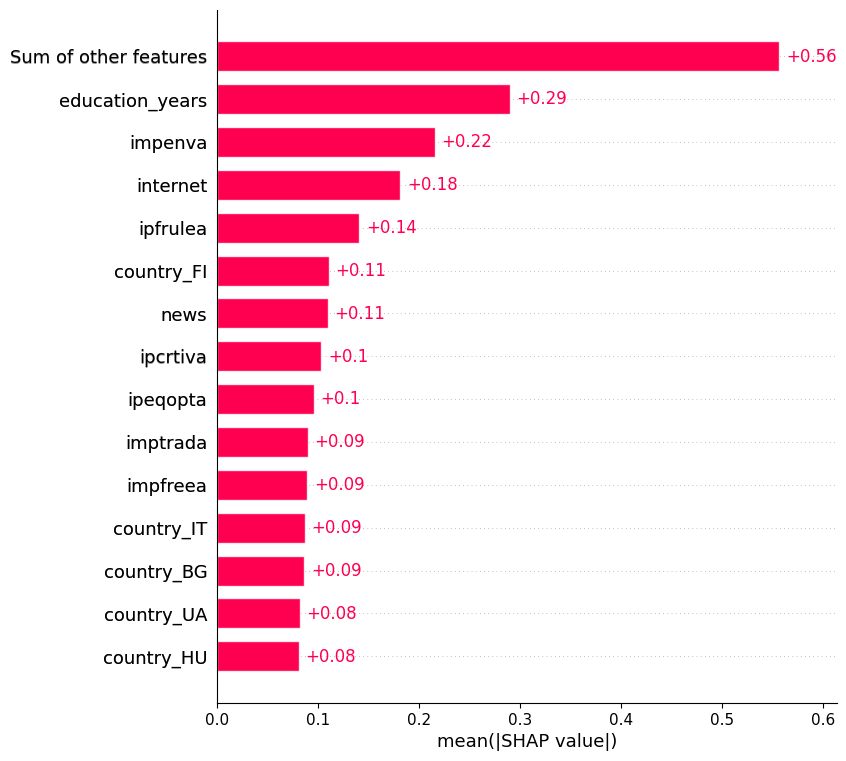

In [69]:
import numpy as np

# --- CUSTOM REORDERING LOGIC ---
# 1. Calculate the mean absolute SHAP values to find the 'top' features
mean_abs_shap = np.abs(shap_values.values).mean(0)
# We want to display 15 items total, so we keep the top 14 and group the rest
top_indices = np.argsort(mean_abs_shap)[-14:] 
other_indices = np.argsort(mean_abs_shap)[:-14]

# 2. Sum the 'Other' features
other_values = shap_values.values[:, other_indices].sum(axis=1, keepdims=True)
other_data = np.zeros((shap_values.data.shape[0], 1)) # Placeholder for data

# 3. Create the new values and names array
# Put 'Other' first, then the top features
new_values = np.hstack([other_values, shap_values.values[:, top_indices]])
new_names = ['Sum of other features'] + [all_feature_names[i] for i in top_indices]

# 4. Create a new Explanation object
# Note: we disable automatic clustering/sorting in the plot to keep our order
top_other_shap = shap.Explanation(
    values=new_values,
    base_values=shap_values.base_values,
    data=None, 
    feature_names=new_names
)

# 5. Plot (Setting cluster_threshold=None or similar often helps keep order)
print("Generating Global Feature Importance (Other on Top)...")
shap.plots.bar(top_other_shap, max_display=15)


Generating Global Aggregated Feature Importance...


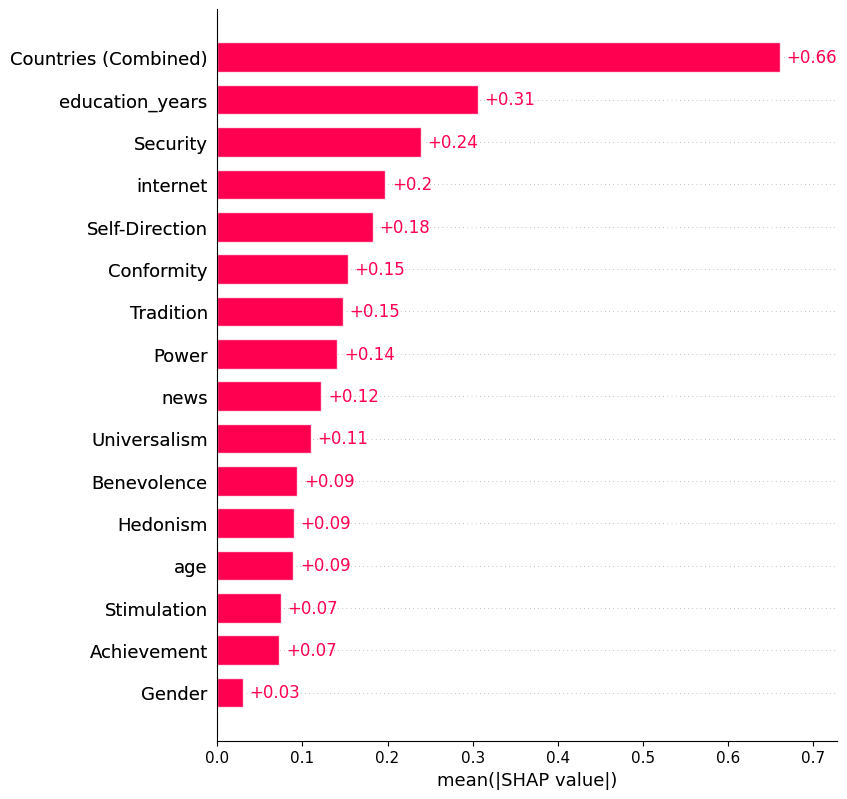

In [70]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

# -----------------------------
# 1. INITIALIZE & COMPUTE SHAP
# -----------------------------
# TreeExplainer is optimized for CatBoost
explainer = shap.TreeExplainer(final_pipeline.named_steps['model'])

# Preprocess holdout data to match model input
X_holdout_preprocessed = final_pipeline.named_steps['preprocessor'].transform(X_holdout)

# Reconstruct feature names from the pipeline
ohe = final_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(categorical_cols).tolist()
all_feature_names = numerical_cols + cat_feature_names

X_holdout_df = pd.DataFrame(X_holdout_preprocessed, columns=all_feature_names)

# Compute SHAP values
shap_values = explainer(X_holdout_df)

# Select positive class (Boycott) if output is multi-dimensional
if len(shap_values.shape) == 3:
    shap_values = shap_values[..., 1]

# -----------------------------
# 2. AGGREGATION LOGIC
# -----------------------------
# Define Schwartz Value Mappings
value_mapping = {
    'Self-Direction': ['ipcrtiva', 'impfreea'],
    'Stimulation':    ['impdiffa', 'iplylfra'],
    'Hedonism':       ['ipgdtima', 'impfuna'],
    'Achievement':    ['ipshabta', 'ipadvnta'],
    'Power':          ['impricha', 'ipsucesa', 'iprspota'],
    'Security':       ['impsafea', 'impenva'],
    'Conformity':     ['ipfrulea'],
    'Tradition':      ['ipudrsta', 'ipmodsta', 'imptrada'],
    'Benevolence':    ['ipstrgva', 'ipbhprpa'],
    'Universalism':   ['ipeqopta', 'iphlppla']
}

# Convert SHAP values to DataFrame for manipulation
shap_df = pd.DataFrame(shap_values.values, columns=X_holdout_df.columns)
aggregated_shap = shap_df.copy()

# Aggregate Schwartz Values
all_value_components = []
for value_name, features in value_mapping.items():
    existing = [f for f in features if f in shap_df.columns]
    if existing:
        aggregated_shap[value_name] = shap_df[existing].sum(axis=1)
        all_value_components.extend(existing)

# Aggregate Countries
country_cols = [c for c in shap_df.columns if c.startswith('country_')]
if country_cols:
    aggregated_shap['Countries (Combined)'] = shap_df[country_cols].sum(axis=1)

# Drop individual components used in aggregation
cols_to_drop = list(set(all_value_components + country_cols))
aggregated_shap = aggregated_shap.drop(columns=cols_to_drop)

# Rename 'gender_2' to 'Gender' for thesis professional look
if 'gender_2' in aggregated_shap.columns:
    aggregated_shap = aggregated_shap.rename(columns={'gender_2': 'Gender'})

# -----------------------------
# 3. FINAL PLOT
# -----------------------------
# Create the new SHAP Explanation object
final_shap_values = shap.Explanation(
    values=aggregated_shap.values,
    base_values=shap_values.base_values,
    data=None, 
    feature_names=aggregated_shap.columns.tolist()
)

print("\nGenerating Global Aggregated Feature Importance...")
# Setting max_display=20 to ensure specific demographic features are visible
shap.plots.bar(final_shap_values, max_display=20)

### Local

Generating Local Explanation for Holdout Sample ID: 1


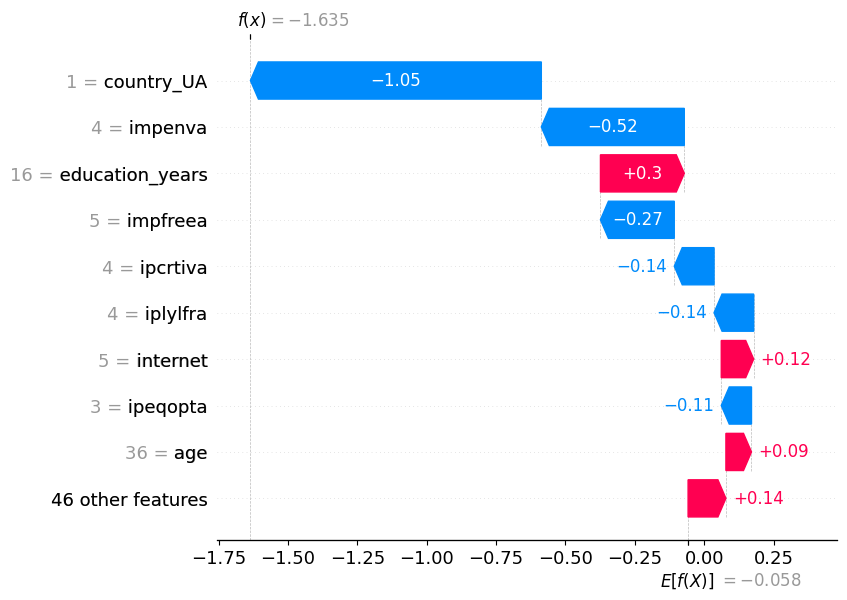

In [71]:
# 4. Local Explanation: Waterfall Plot
# Select a specific instance from your holdout set (e.g., sample at index 1)
sample_id = 1
print(f"Generating Local Explanation for Holdout Sample ID: {sample_id}")
shap.plots.waterfall(shap_values[sample_id])


--- Case 1: The Clear Boycotter (True Positive) ---
Sample Index: 2 | Actual: 1 | Pred Prob: 0.548


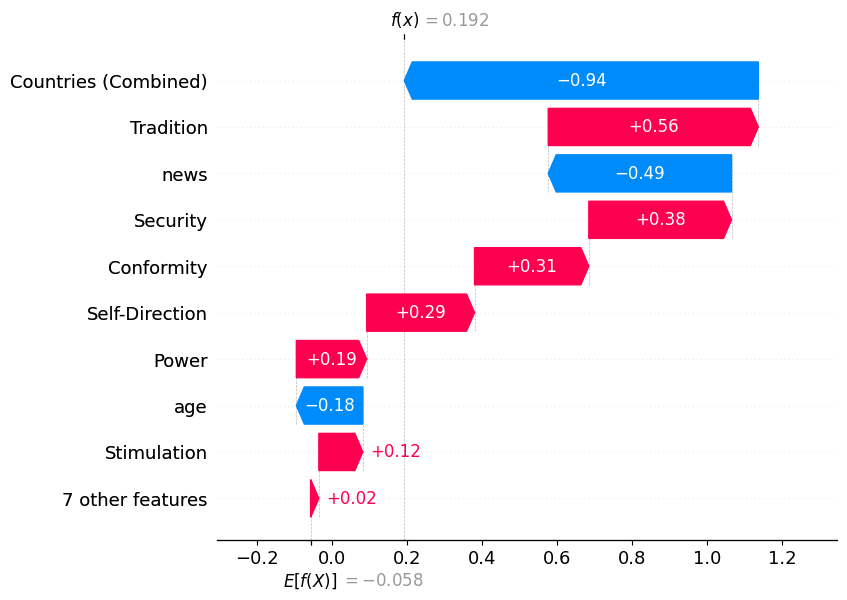


--- Case 2: The Clear Non-Boycotter (True Negative) ---
Sample Index: 0 | Actual: 0 | Pred Prob: 0.076


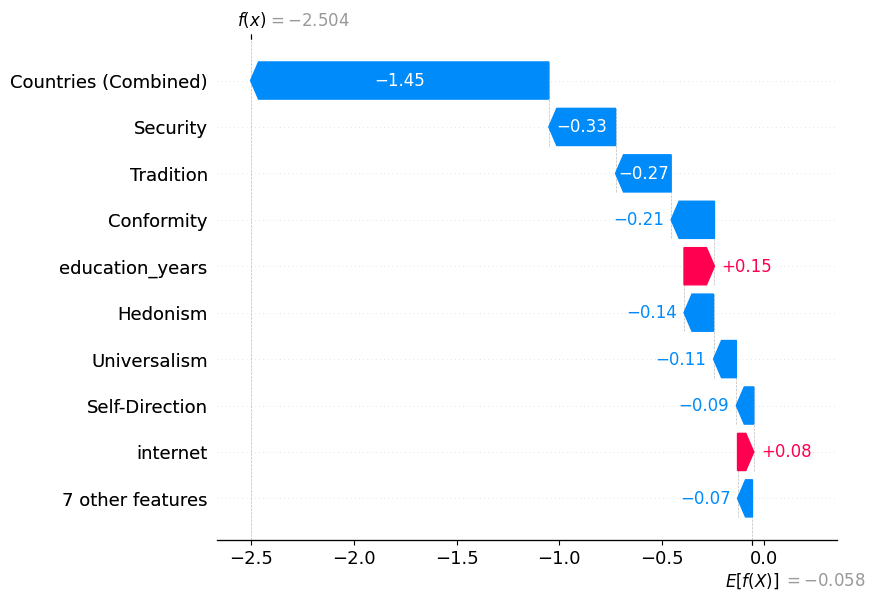


--- Case 3: The Surprise (False Negative / Blind Spot) ---
Sample Index: 5 | Actual: 1 | Pred Prob: 0.402


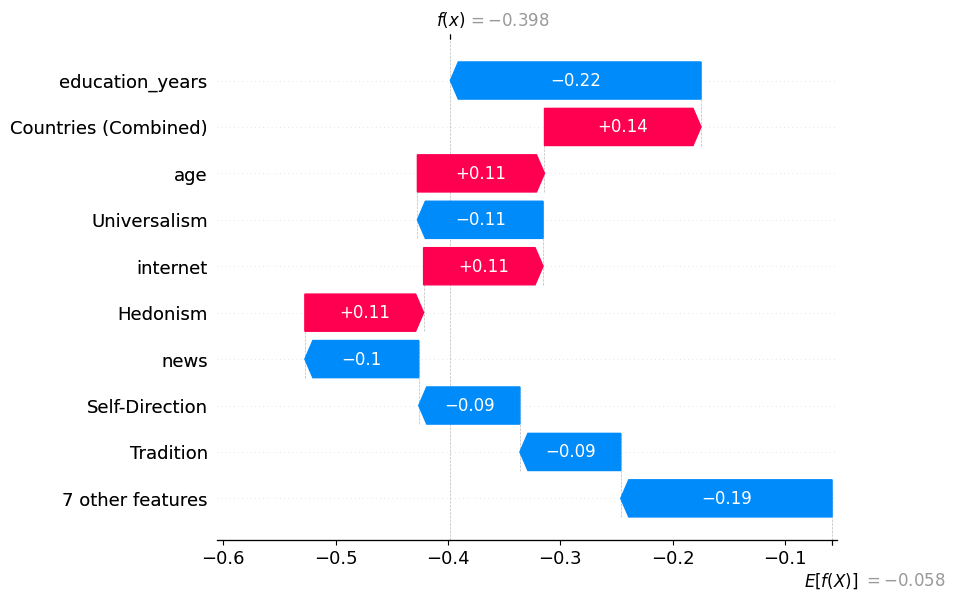


--- Case 4: The Boundary Case (Uncertain) ---
Sample Index: 451 | Actual: 0 | Pred Prob: 0.500


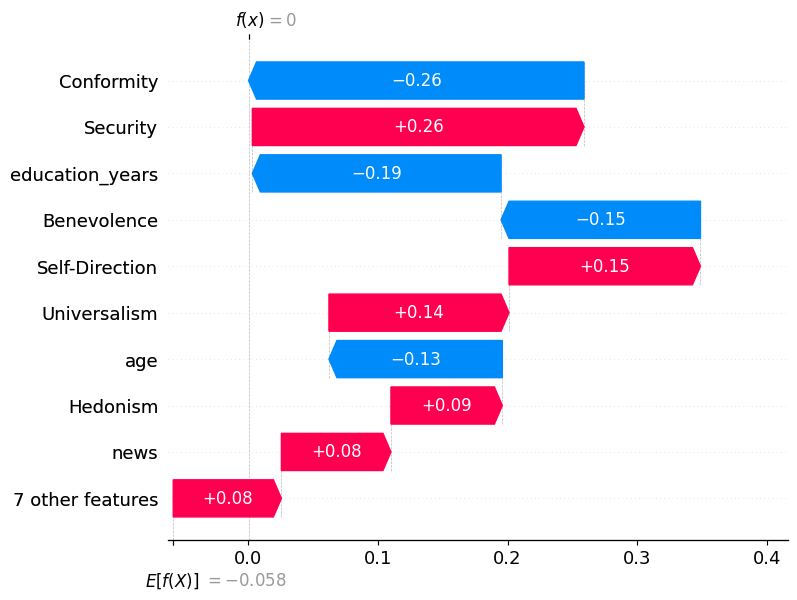

In [72]:
import numpy as np
import shap

# 1. First, ensure you have your holdout predictions ready
y_holdout_pred = final_pipeline.predict(X_holdout)
# Also get probabilities to find the 'boundary' case
y_holdout_proba = final_pipeline.predict_proba(X_holdout)[:, 1]

# 2. Identify indices for the 4 categories
# True Positive (TP): Predict Boycott, Actually Boycotted
tp_idx = np.where((y_holdout == 1) & (y_holdout_pred == 1))[0][0]

# True Negative (TN): Predict No Boycott, Actually didn't
tn_idx = np.where((y_holdout == 0) & (y_holdout_pred == 0))[0][0]

# False Negative (FN): Predict No Boycott, but they ACTUALLY boycotted (The Surprise)
fn_idx = np.where((y_holdout == 1) & (y_holdout_pred == 0))[0][0]

# Boundary Case: Prediction is closest to 0.5 (uncertain/on the fence)
boundary_idx = np.argmin(np.abs(y_holdout_proba - 0.5))

case_indices = {
    "Case 1: The Clear Boycotter (True Positive)": tp_idx,
    "Case 2: The Clear Non-Boycotter (True Negative)": tn_idx,
    "Case 3: The Surprise (False Negative / Blind Spot)": fn_idx,
    "Case 4: The Boundary Case (Uncertain)": boundary_idx
}

# 3. Generate the 4 waterfall plots
# We use the 'final_shap_values' explanation object created in the previous step
for title, idx in case_indices.items():
    print(f"\n--- {title} ---")
    print(f"Sample Index: {idx} | Actual: {y_holdout.iloc[idx]} | Pred Prob: {y_holdout_proba[idx]:.3f}")
    
    # Generate the waterfall plot for this specific index
    # We use our aggregated explanation object
    shap.plots.waterfall(final_shap_values[idx])


--- Case 1: The Clear Boycotter (True Positive) ---
Sample Index: 15 | Actual: 1 | Pred Prob: 0.734


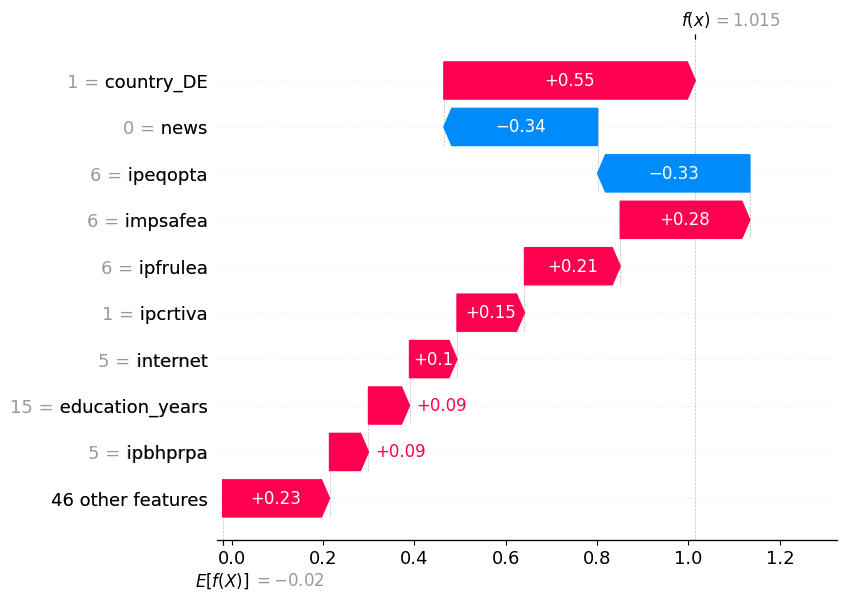


--- Case 2: The Clear Non-Boycotter (True Negative) ---
Sample Index: 0 | Actual: 0 | Pred Prob: 0.132


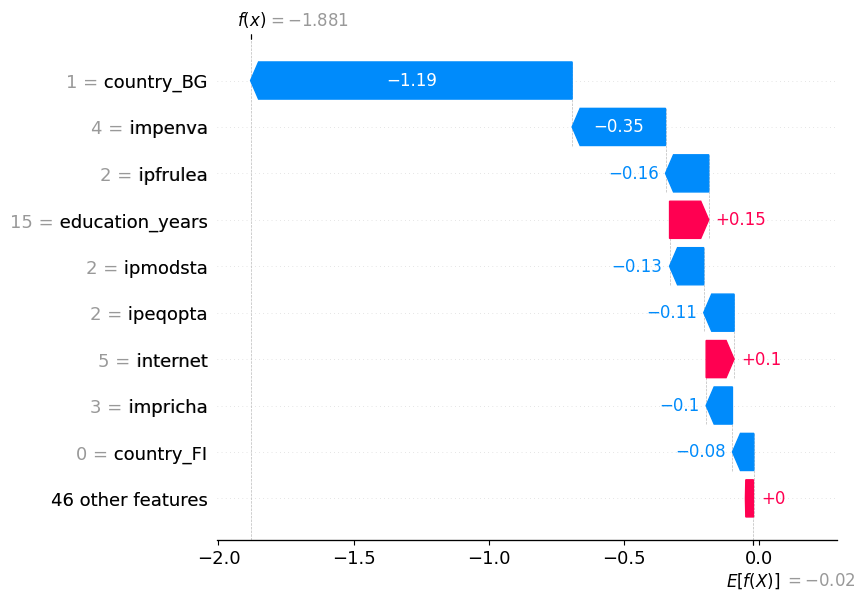


--- Case 3: The Surprise (False Negative) ---
Sample Index: 2 | Actual: 1 | Pred Prob: 0.465


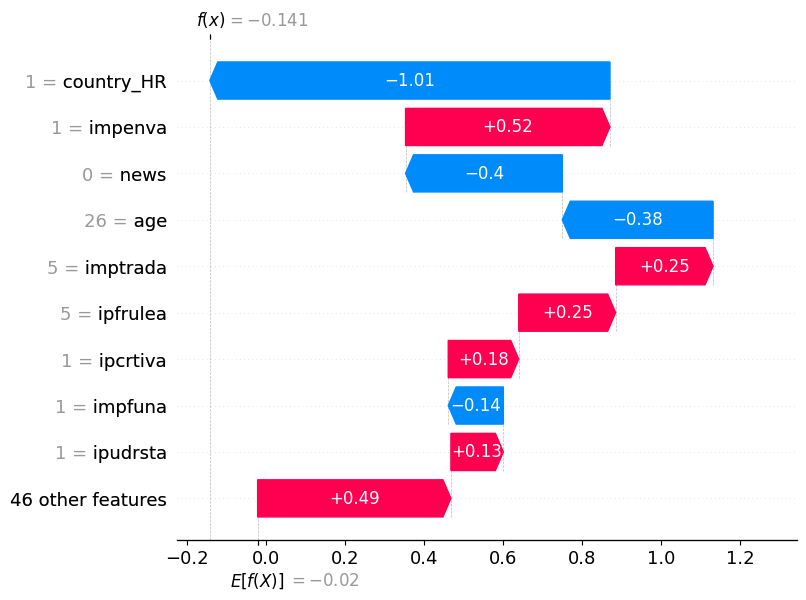


--- Case 4: The Boundary Case (Uncertain) ---
Sample Index: 715 | Actual: 0 | Pred Prob: 0.500


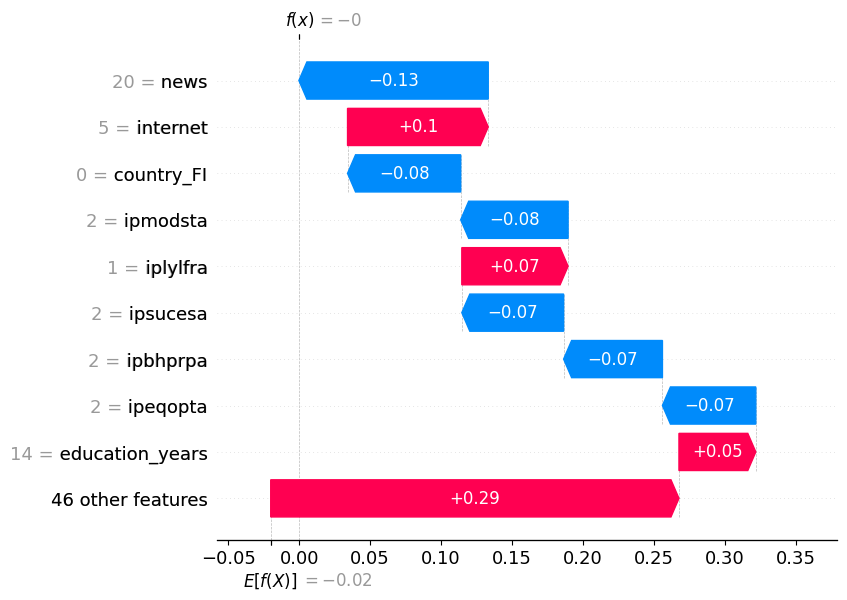

In [53]:
import numpy as np
import shap

# 1. Get predictions and probabilities from your holdout set
y_holdout_pred = final_pipeline.predict(X_holdout)
y_holdout_proba = final_pipeline.predict_proba(X_holdout)[:, 1]

# 2. Identify indices for the 4 scenarios
# True Positive (TP): Model correctly predicted a boycott
tp_idx = np.where((y_holdout == 1) & (y_holdout_pred == 1))[0][0]

# True Negative (TN): Model correctly predicted no boycott
tn_idx = np.where((y_holdout == 0) & (y_holdout_pred == 0))[0][0]

# False Negative (FN): The 'Surprise' - they boycotted, but the model missed it
fn_idx = np.where((y_holdout == 1) & (y_holdout_pred == 0))[0][0]

# Boundary Case: The person the model is most 'unsure' about (closest to 0.5)
boundary_idx = np.argmin(np.abs(y_holdout_proba - 0.5))

case_indices = {
    "Case 1: The Clear Boycotter (True Positive)": tp_idx,
    "Case 2: The Clear Non-Boycotter (True Negative)": tn_idx,
    "Case 3: The Surprise (False Negative)": fn_idx,
    "Case 4: The Boundary Case (Uncertain)": boundary_idx
}

# 3. Generate waterfall plots using the original 'shap_values' object
# This will show 'impenva', 'ipcrtiva', 'gender_2', etc.
for title, idx in case_indices.items():
    print(f"\n--- {title} ---")
    print(f"Sample Index: {idx} | Actual: {y_holdout.iloc[idx]} | Pred Prob: {y_holdout_proba[idx]:.3f}")
    
    # Use the original shap_values calculated before aggregation
    shap.plots.waterfall(shap_values[idx])

## Error Analysis

Outcome type counts:
error_type
true_negative     6313
false_positive    1506
true_positive     1092
false_negative     693
Name: count, dtype: int64

False Negatives (missed boycotts): 693
False Positives (wrongly flagged): 1506

--- FALSE NEGATIVES (missed boycotts) ---
             news    internet         age  education_years    ipcrtiva  \
count  693.000000  692.000000  685.000000       681.000000  692.000000   
mean    80.922078    4.352601   49.452555        13.409692    2.598266   
std    112.205966    1.229148   18.292367         3.717743    1.324553   
min      0.000000    1.000000   15.000000         0.000000    1.000000   
25%     30.000000    4.000000   35.000000        11.000000    2.000000   
50%     60.000000    5.000000   50.000000        13.000000    2.000000   
75%     90.000000    5.000000   64.000000        16.000000    3.000000   
max    900.000000    5.000000   90.000000        30.000000    6.000000   

         impricha    ipeqopta    ipshabta    impsafea    imp

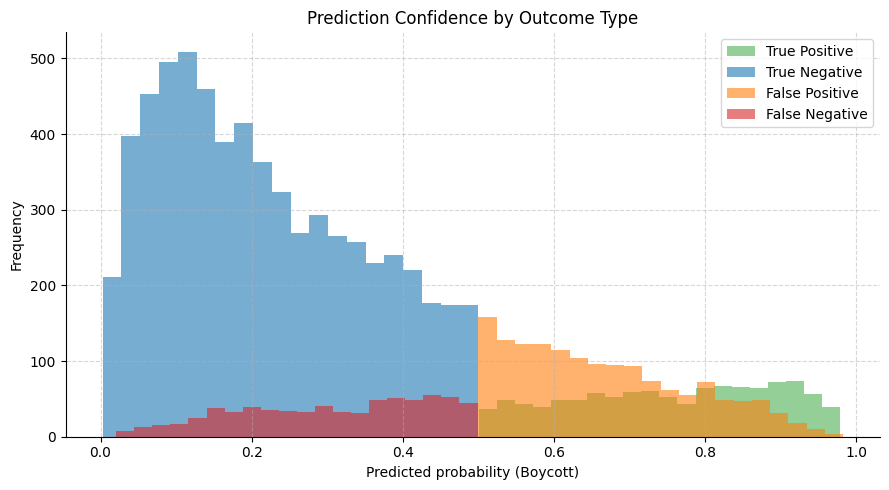

/var/folders/p5/dd0mn9h16750wt2b1yj0qkf80000gn/T/ipykernel_95273/1231549286.py:122: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
/var/folders/p5/dd0mn9h16750wt2b1yj0qkf80000gn/T/ipykernel_95273/1231549286.py:122: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
/var/folders/p5/dd0mn9h16750wt2b1yj0qkf80000gn/T/ipykernel_95273/1231549286.py:122: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
/var/folders/p5/dd0mn9h16750wt2b1yj0qkf80000gn/T/ipykernel_95273/1231549286.py:122: UserWarning: set_ticklabels() should only be used with a fixed number 

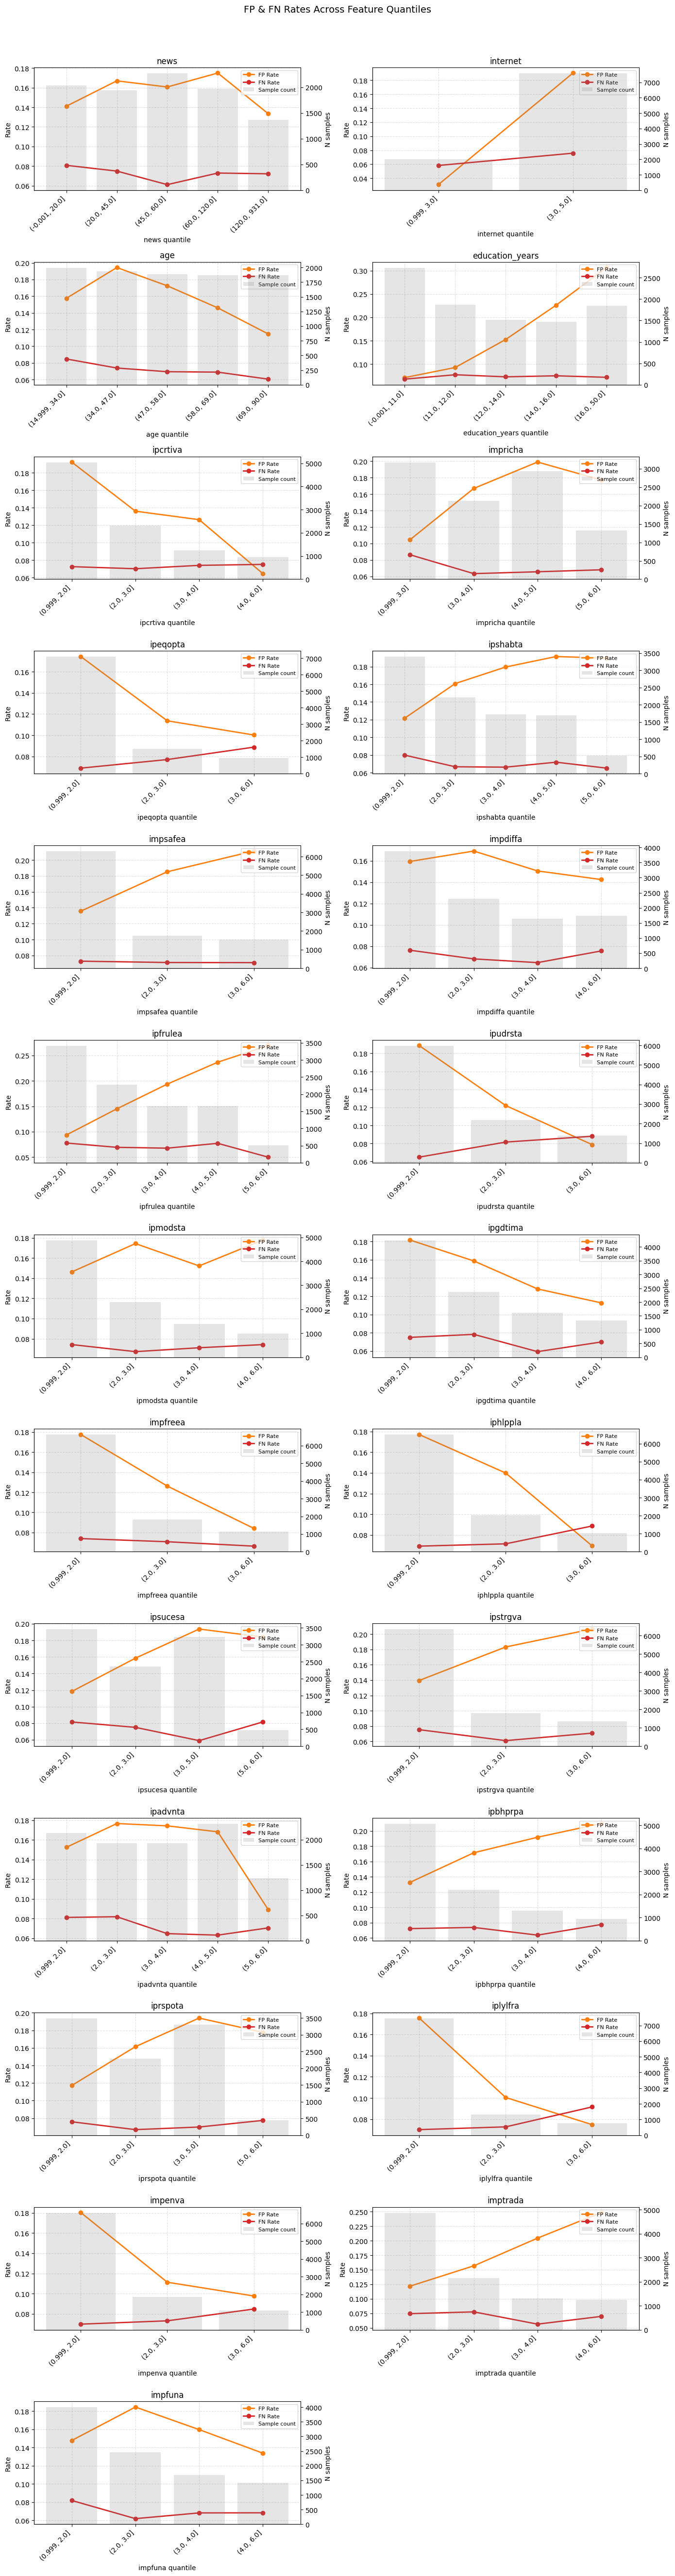

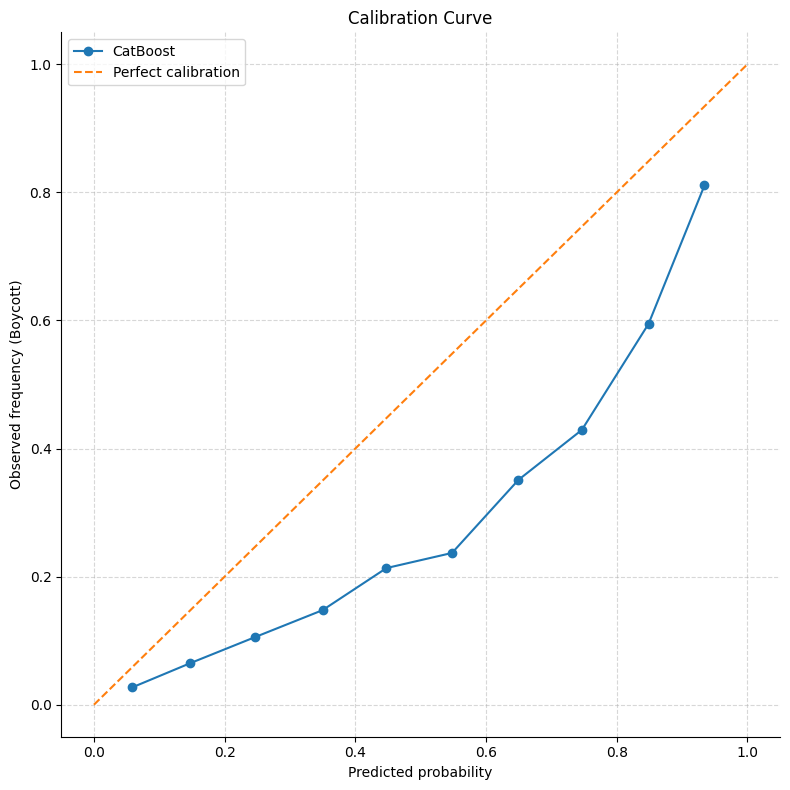

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# -------------------------------------------------------
# ERROR ANALYSIS — Boycott Classification
# -------------------------------------------------------

# -----------------------------
# STEP 1: Build results table
# Uses original (pre-processed) X_holdout features for interpretability
# -----------------------------
results_clf = X_holdout.copy().reset_index(drop=True)
results_clf["y_true"]  = y_holdout.reset_index(drop=True)
results_clf["y_pred"]  = y_holdout_pred
results_clf["y_proba"] = y_holdout_prob

# Label each sample by outcome type
def assign_error_type(row):
    if row["y_true"] == 1 and row["y_pred"] == 1:
        return "true_positive"
    elif row["y_true"] == 0 and row["y_pred"] == 0:
        return "true_negative"
    elif row["y_true"] == 0 and row["y_pred"] == 1:
        return "false_positive"
    else:
        return "false_negative"

results_clf["error_type"] = results_clf.apply(assign_error_type, axis=1)

print("Outcome type counts:")
print(results_clf["error_type"].value_counts())

# -----------------------------
# STEP 2: Inspect the actual errors
# -----------------------------
false_negatives = results_clf[results_clf["error_type"] == "false_negative"]
false_positives = results_clf[results_clf["error_type"] == "false_positive"]

print(f"\nFalse Negatives (missed boycotts): {len(false_negatives)}")
print(f"False Positives (wrongly flagged): {len(false_positives)}")

print("\n--- FALSE NEGATIVES (missed boycotts) ---")
print(false_negatives.describe())

print("\n--- FALSE POSITIVES (wrongly flagged) ---")
print(false_positives.describe())

# -----------------------------
# STEP 3: Prediction confidence by outcome type
# (from lecture section 4.2.3)
# -----------------------------
colors = {
    "true_positive":  "#4CAF50",   # green
    "true_negative":  "#1f77b4",   # blue
    "false_positive": "#ff7f0e",   # orange
    "false_negative": "#d62728"    # red
}

plt.figure(figsize=(9, 5))
for error_type, color in colors.items():
    subset = results_clf.loc[results_clf["error_type"] == error_type, "y_proba"]
    if len(subset) > 0:
        plt.hist(subset, bins=20, alpha=0.6,
                 label=error_type.replace("_", " ").title(), color=color)

plt.xlabel("Predicted probability (Boycott)")
plt.ylabel("Frequency")
plt.title("Prediction Confidence by Outcome Type")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# -----------------------------
# STEP 4: Binned error analysis per numerical feature
# (from lecture section 4.2.4)
# Run for each numerical feature to spot where errors cluster
# -----------------------------
n_bins = 5  # fewer bins since holdout set is smaller than full data

fig_rows = int(np.ceil(len(numerical_cols) / 2))
fig, axes = plt.subplots(fig_rows, 2, figsize=(14, 4 * fig_rows))
axes = axes.flatten()

for i, feature in enumerate(numerical_cols):
    if feature not in results_clf.columns:
        continue

    temp = results_clf[[feature, "y_true", "y_pred"]].copy()
    try:
        temp[f"{feature}_bin"] = pd.qcut(temp[feature], q=n_bins, duplicates="drop")
    except Exception:
        continue  # skip if not enough unique values

    summary = temp.groupby(f"{feature}_bin", observed=False).apply(
        lambda df: pd.Series({
            "n_samples": len(df),
            "fp_rate":   ((df["y_true"] == 0) & (df["y_pred"] == 1)).mean(),
            "fn_rate":   ((df["y_true"] == 1) & (df["y_pred"] == 0)).mean(),
        })
    ).reset_index()

    summary["group_label"] = summary[f"{feature}_bin"].astype(str)

    ax1 = axes[i]
    ax2 = ax1.twinx()

    ax2.bar(summary["group_label"], summary["n_samples"], alpha=0.2,
            color="grey", label="Sample count")
    ax1.plot(summary["group_label"], summary["fp_rate"], marker="o",
             linewidth=2, label="FP Rate", color="#ff7f0e")
    ax1.plot(summary["group_label"], summary["fn_rate"], marker="o",
             linewidth=2, label="FN Rate", color="#d62728")

    ax1.set_title(feature)
    ax1.set_xlabel(f"{feature} quantile")
    ax1.set_ylabel("Rate")
    ax2.set_ylabel("N samples")
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
    ax1.grid(True, linestyle="--", alpha=0.4)
    ax1.spines[["top", "right"]].set_visible(False)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=8)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


fig.suptitle("FP & FN Rates Across Feature Quantiles", fontsize=14, y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.995)  # leaves room for the suptitle
plt.show()

# -----------------------------
# STEP 5: Calibration curve
# (from lecture section 4.2.5)
# Are the predicted probabilities trustworthy?
# -----------------------------
prob_true, prob_pred_cal = calibration_curve(y_holdout, y_holdout_prob, n_bins=10)

plt.figure(figsize=(8, 8))
plt.plot(prob_pred_cal, prob_true, marker="o", label="CatBoost")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency (Boycott)")
plt.title("Calibration Curve")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Subgroup Analysis (Country)

Countries included: 30

Overall F1: 0.498 | Precision: 0.420 | Recall: 0.612

Per-country metrics:
         n_samples  boycott_rate     f1  precision  recall  fp_rate  fn_rate
country                                                                     
PT           244.0         0.053  0.000      0.000   0.000    0.000    1.000
UA           514.0         0.064  0.000      0.000   0.000    0.012    1.000
ME           312.0         0.138  0.071      0.154   0.047    0.041    0.953
CY           132.0         0.121  0.083      0.125   0.062    0.060    0.938
IT           539.0         0.058  0.095      0.182   0.065    0.018    0.935
SK           273.0         0.132  0.100      0.500   0.056    0.008    0.944
RS           269.0         0.093  0.150      0.200   0.120    0.049    0.880
SI           236.0         0.097  0.158      0.200   0.130    0.056    0.870
HR           275.0         0.062  0.194      0.214   0.176    0.043    0.824
LT           254.0         0.110  0.254      0.229   0

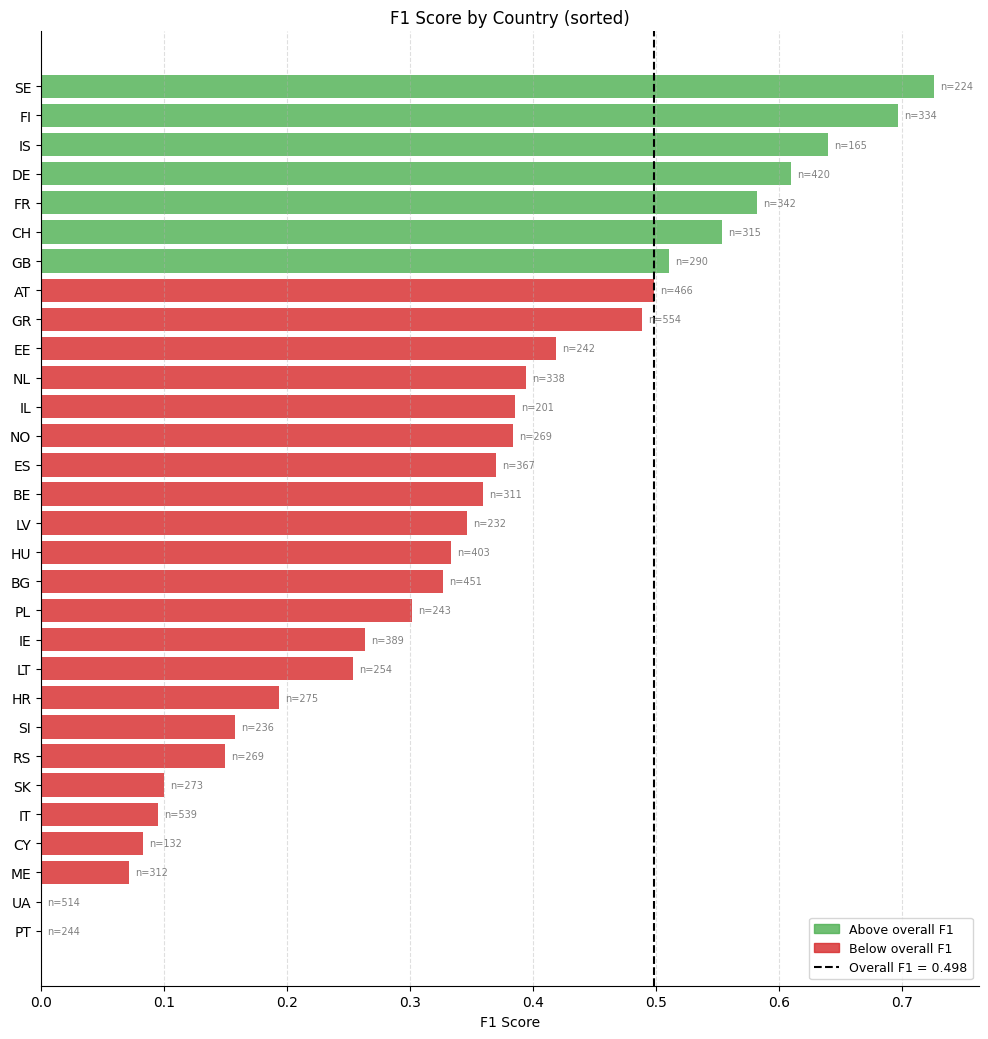

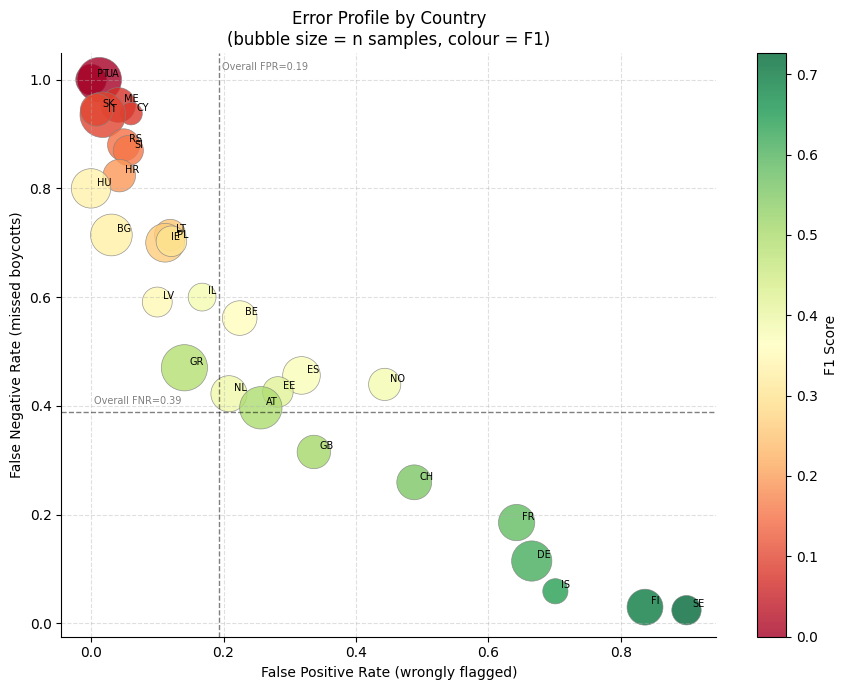

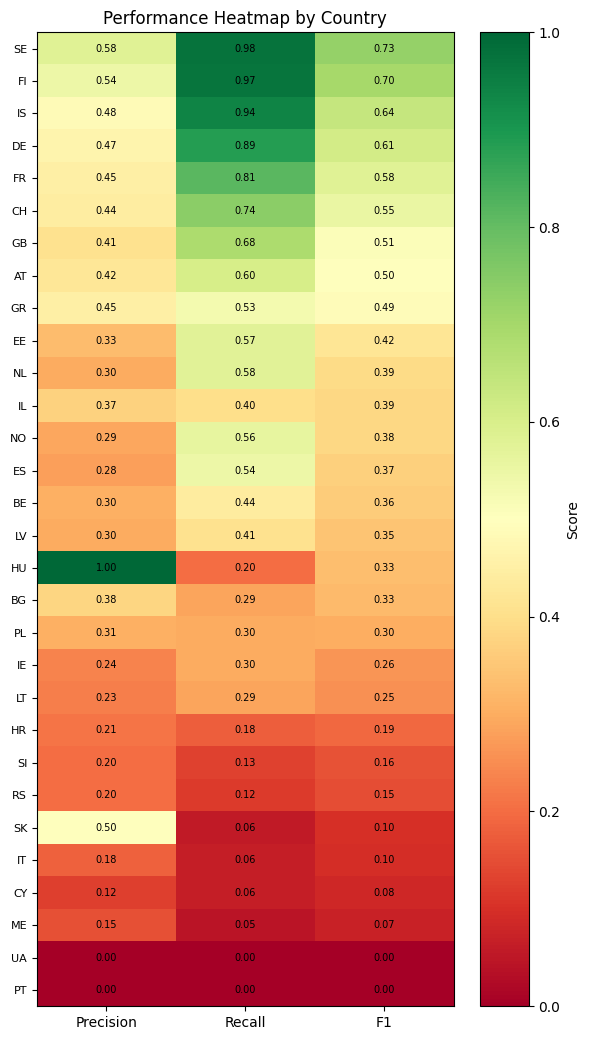


--- WORST 5 COUNTRIES BY F1 ---
         n_samples  boycott_rate     f1  precision  recall
country                                                   
PT           244.0         0.053  0.000      0.000   0.000
UA           514.0         0.064  0.000      0.000   0.000
ME           312.0         0.138  0.071      0.154   0.047
CY           132.0         0.121  0.083      0.125   0.062
IT           539.0         0.058  0.095      0.182   0.065

--- HIGHEST FALSE NEGATIVE RATE (most missed boycotts) ---
         n_samples  boycott_rate  fn_rate     f1
country                                         
PT           244.0         0.053    1.000  0.000
UA           514.0         0.064    1.000  0.000
ME           312.0         0.138    0.953  0.071
SK           273.0         0.132    0.944  0.100
CY           132.0         0.121    0.938  0.083


In [76]:
# -------------------------------------------------------
# SUBGROUP ANALYSIS — Performance Across Countries
# -------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import f1_score, precision_score, recall_score

# -----------------------------
# STEP 1: Build per-country metrics table
# Assumes your holdout set has a 'cntry' column (ESS country code)
# Adjust the column name if yours differs
# -----------------------------
results_clf = X_holdout.copy().reset_index(drop=True)
results_clf["y_true"]  = y_holdout.reset_index(drop=True)
results_clf["y_pred"]  = y_holdout_pred
results_clf["y_proba"] = y_holdout_prob

country_col = "country"   

def country_metrics(df):
    yt = df["y_true"]
    yp = df["y_pred"]
    n  = len(df)
    n_pos = yt.sum()

    # Skip countries with too few positive cases to compute meaningful metrics
    if n_pos < 3 or (n - n_pos) < 3:
        return None

    return pd.Series({
        "n_samples":     n,
        "boycott_rate":  yt.mean(),
        "f1":            f1_score(yt, yp, zero_division=0),
        "precision":     precision_score(yt, yp, zero_division=0),
        "recall":        recall_score(yt, yp, zero_division=0),
        "fp_rate":       ((yt == 0) & (yp == 1)).sum() / max((yt == 0).sum(), 1),
        "fn_rate":       ((yt == 1) & (yp == 0)).sum() / max((yt == 1).sum(), 1),
    })

by_country = (
    results_clf.groupby(country_col)
    .apply(country_metrics)
    .dropna()
    .sort_values("f1", ascending=True)  # sort for horizontal bar charts
)

# Overall baseline to compare against
overall_f1   = f1_score(y_holdout, y_holdout_pred)
overall_prec = precision_score(y_holdout, y_holdout_pred)
overall_rec  = recall_score(y_holdout, y_holdout_pred)

print(f"Countries included: {len(by_country)}")
print(f"\nOverall F1: {overall_f1:.3f} | Precision: {overall_prec:.3f} | Recall: {overall_rec:.3f}")
print("\nPer-country metrics:")
print(by_country.round(3).to_string())


# -----------------------------
# STEP 2: Horizontal bar chart — F1 per country
# Sorted, colour-coded by whether they beat overall F1
# -----------------------------
fig, ax = plt.subplots(figsize=(10, max(6, len(by_country) * 0.35)))

colors = ["#4CAF50" if v >= overall_f1 else "#d62728" for v in by_country["f1"]]
bars = ax.barh(by_country.index, by_country["f1"], color=colors, alpha=0.8)

ax.axvline(overall_f1, color="black", linestyle="--", linewidth=1.5,
           label=f"Overall F1 = {overall_f1:.3f}")

ax.set_xlabel("F1 Score")
ax.set_title("F1 Score by Country (sorted)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4, axis="x")
ax.spines[["top", "right"]].set_visible(False)

# Annotate with sample size
for bar, (_, row) in zip(bars, by_country.iterrows()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"n={int(row['n_samples'])}", va="center", fontsize=7, color="grey")

green_patch = mpatches.Patch(color="#4CAF50", alpha=0.8, label="Above overall F1")
red_patch   = mpatches.Patch(color="#d62728", alpha=0.8, label="Below overall F1")
ax.legend(handles=[green_patch, red_patch,
                   plt.Line2D([0], [0], color="black", linestyle="--")],
          labels=["Above overall F1", "Below overall F1",
                  f"Overall F1 = {overall_f1:.3f}"],
          fontsize=9)

plt.tight_layout()
plt.show()


# -----------------------------
# STEP 3: FP rate vs FN rate scatter — one dot per country
# Reveals whether errors are systematic (missing boycotts vs over-flagging)
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 7))

scatter = ax.scatter(
    by_country["fp_rate"],
    by_country["fn_rate"],
    s=by_country["n_samples"] * 2,   # bubble size = sample size
    c=by_country["f1"],
    cmap="RdYlGn",
    alpha=0.8,
    edgecolors="grey",
    linewidths=0.5
)

# Label each country
for country, row in by_country.iterrows():
    ax.annotate(country,
                (row["fp_rate"], row["fn_rate"]),
                fontsize=7, ha="left",
                xytext=(4, 2), textcoords="offset points")

plt.colorbar(scatter, ax=ax, label="F1 Score")
ax.set_xlabel("False Positive Rate (wrongly flagged)")
ax.set_ylabel("False Negative Rate (missed boycotts)")
ax.set_title("Error Profile by Country\n(bubble size = n samples, colour = F1)")
ax.grid(True, linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

# Reference lines at overall rates
overall_fpr = ((y_holdout == 0) & (y_holdout_pred == 1)).sum() / (y_holdout == 0).sum()
overall_fnr = ((y_holdout == 1) & (y_holdout_pred == 0)).sum() / (y_holdout == 1).sum()
ax.axvline(overall_fpr, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.axhline(overall_fnr, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.text(overall_fpr + 0.005, ax.get_ylim()[1] * 0.97,
        f"Overall FPR={overall_fpr:.2f}", fontsize=7, color="grey")
ax.text(0.005, overall_fnr + 0.015,
        f"Overall FNR={overall_fnr:.2f}", fontsize=7, color="grey")

plt.tight_layout()
plt.show()


# -----------------------------
# STEP 4: Heatmap — Precision / Recall / F1 across countries
# Good for spotting patterns across all three metrics at once
# -----------------------------
metrics_to_show = ["precision", "recall", "f1"]
heatmap_data = by_country[metrics_to_show].sort_values("f1", ascending=False)

fig, ax = plt.subplots(figsize=(6, max(6, len(heatmap_data) * 0.35)))

im = ax.imshow(heatmap_data.values, aspect="auto", cmap="RdYlGn",
               vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="Score")

ax.set_xticks(range(len(metrics_to_show)))
ax.set_xticklabels(["Precision", "Recall", "F1"], fontsize=10)
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data.index, fontsize=8)
ax.set_title("Performance Heatmap by Country")

# Annotate cells with values
for i in range(len(heatmap_data)):
    for j in range(len(metrics_to_show)):
        val = heatmap_data.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=7, color="black")

plt.tight_layout()
plt.show()


# -----------------------------
# STEP 5: Print worst performing countries
# -----------------------------
print("\n--- WORST 5 COUNTRIES BY F1 ---")
print(by_country.nsmallest(5, "f1")[["n_samples", "boycott_rate", "f1", "precision", "recall"]].round(3))

print("\n--- HIGHEST FALSE NEGATIVE RATE (most missed boycotts) ---")
print(by_country.nlargest(5, "fn_rate")[["n_samples", "boycott_rate", "fn_rate", "f1"]].round(3))

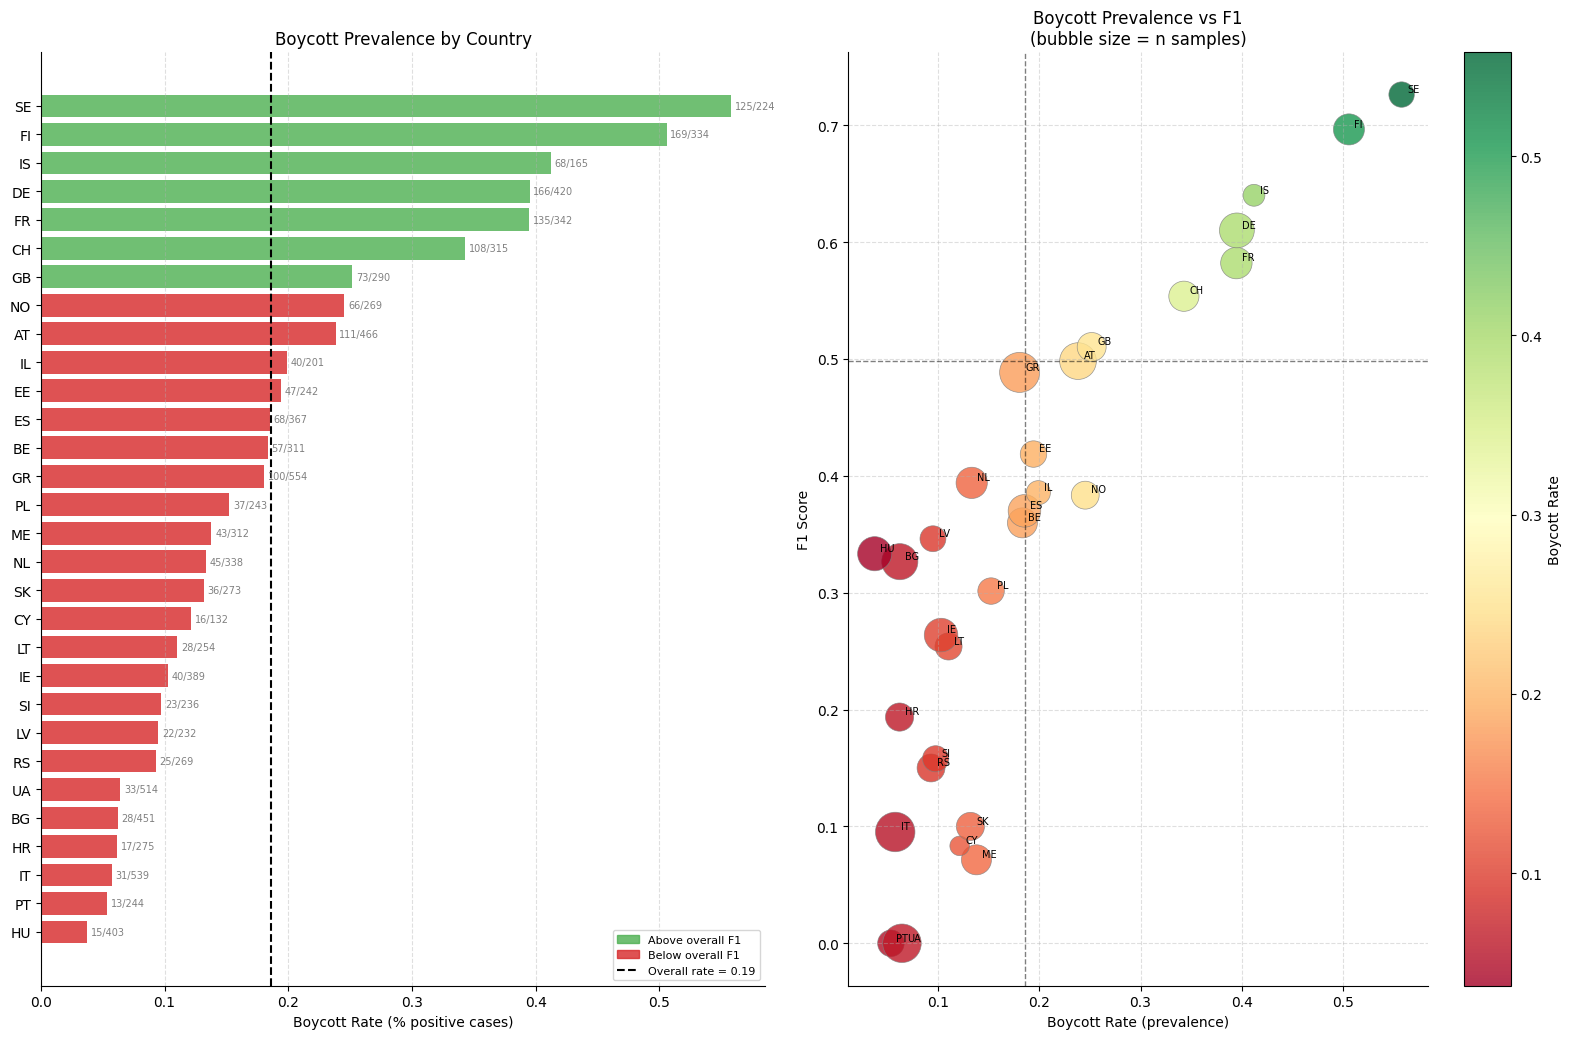


Full country summary (sorted by F1):
         n_samples  n_boycotts  boycott_rate     f1  fn_rate  fp_rate
country                                                              
SE           224.0         125         0.558  0.726    0.024    0.899
FI           334.0         169         0.506  0.696    0.030    0.836
IS           165.0          68         0.412  0.640    0.059    0.701
DE           420.0         166         0.395  0.610    0.114    0.665
FR           342.0         135         0.395  0.582    0.185    0.643
CH           315.0         108         0.343  0.554    0.259    0.488
GB           290.0          73         0.252  0.510    0.315    0.336
AT           466.0         111         0.238  0.498    0.396    0.256
GR           554.0         100         0.181  0.488    0.470    0.141
EE           242.0          47         0.194  0.419    0.426    0.282
NL           338.0          45         0.133  0.394    0.422    0.208
IL           201.0          40         0.199  0.386 

In [77]:
# -----------------------------
# Boycott Prevalence vs F1 by Country
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(by_country) * 0.35)))

# Sort by boycott rate for the left panel
by_country_prev = by_country.sort_values("boycott_rate", ascending=True)

# --- Panel 1: Boycott prevalence per country ---
colors_prev = ["#4CAF50" if v >= overall_f1 else "#d62728" 
               for v in by_country_prev["f1"]]

bars = axes[0].barh(by_country_prev.index, by_country_prev["boycott_rate"],
                    color=colors_prev, alpha=0.8)

# Overall boycott rate baseline
overall_boycott_rate = y_holdout.mean()
axes[0].axvline(overall_boycott_rate, color="black", linestyle="--",
                linewidth=1.5, label=f"Overall rate = {overall_boycott_rate:.2f}")

axes[0].set_xlabel("Boycott Rate (% positive cases)")
axes[0].set_title("Boycott Prevalence by Country")
axes[0].grid(True, linestyle="--", alpha=0.4, axis="x")
axes[0].spines[["top", "right"]].set_visible(False)

# Annotate with raw counts
for bar, (_, row) in zip(bars, by_country_prev.iterrows()):
    n_boycott = int(round(row["boycott_rate"] * row["n_samples"]))
    axes[0].text(bar.get_width() + 0.003,
                 bar.get_y() + bar.get_height() / 2,
                 f"{n_boycott}/{int(row['n_samples'])}",
                 va="center", fontsize=7, color="grey")

green_patch = mpatches.Patch(color="#4CAF50", alpha=0.8, label="Above overall F1")
red_patch   = mpatches.Patch(color="#d62728", alpha=0.8, label="Below overall F1")
axes[0].legend(handles=[green_patch, red_patch,
                         plt.Line2D([0], [0], color="black", linestyle="--")],
               labels=["Above overall F1", "Below overall F1",
                       f"Overall rate = {overall_boycott_rate:.2f}"],
               fontsize=8)

# --- Panel 2: Scatter — boycott prevalence vs F1 ---
# This directly shows whether low F1 = low prevalence
sc = axes[1].scatter(
    by_country["boycott_rate"],
    by_country["f1"],
    s=by_country["n_samples"] * 1.5,
    c=by_country["boycott_rate"],
    cmap="RdYlGn",
    alpha=0.8,
    edgecolors="grey",
    linewidths=0.5
)

for country, row in by_country.iterrows():
    axes[1].annotate(country,
                     (row["boycott_rate"], row["f1"]),
                     fontsize=7, ha="left",
                     xytext=(4, 2), textcoords="offset points")

plt.colorbar(sc, ax=axes[1], label="Boycott Rate")
axes[1].axvline(overall_boycott_rate, color="black", linestyle="--",
                linewidth=1, alpha=0.5)
axes[1].axhline(overall_f1, color="black", linestyle="--",
                linewidth=1, alpha=0.5)
axes[1].set_xlabel("Boycott Rate (prevalence)")
axes[1].set_ylabel("F1 Score")
axes[1].set_title("Boycott Prevalence vs F1\n(bubble size = n samples)")
axes[1].grid(True, linestyle="--", alpha=0.4)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# -----------------------------
# Print summary table
# -----------------------------
summary_table = by_country[["n_samples", "boycott_rate", "f1", "fn_rate", "fp_rate"]].copy()
summary_table["n_boycotts"] = (summary_table["boycott_rate"] * summary_table["n_samples"]).round().astype(int)
summary_table = summary_table[["n_samples", "n_boycotts", "boycott_rate", "f1", "fn_rate", "fp_rate"]]
summary_table = summary_table.sort_values("f1", ascending=False)

print("\nFull country summary (sorted by F1):")
print(summary_table.round(3).to_string())

print("\n--- Countries with fewer than 10 boycott cases ---")
low_prev = summary_table[summary_table["n_boycotts"] < 10]
print(low_prev[["n_samples", "n_boycotts", "boycott_rate", "f1"]].round(3).to_string())

=== Prevalence–F1 Correlation ===
Pearson  r  = 0.857  (p = 0.0000)
Spearman rho = 0.843  (p = 0.0000)

=== Norway Error Profile ===
N samples:      269
Boycott rate:   0.245
F1:             0.383
Precision:      0.291
Recall:         0.561
FP rate:        0.335
FN rate:        0.108

=== Feature Means: Norway vs High-F1 Countries vs Overall ===
                news  internet     age  education_years  ipcrtiva  impricha  ipeqopta  ipshabta  impsafea  impdiffa  ipfrulea  ipudrsta  ipmodsta  ipgdtima  impfreea  iphlppla  ipsucesa  ipstrgva  ipadvnta  ipbhprpa  iprspota  iplylfra  impenva  imptrada  impfuna
Norway        76.190     4.851  47.513           14.940     2.596     4.478     2.015     3.974     3.067     3.546     3.015     2.357     3.275     3.257     2.401     2.126     3.410     2.776     3.743     2.519     3.530     1.818    2.586     3.201    3.082
High-F1 avg  103.076     4.537  51.889           14.489     2.535     4.595     1.850     3.789     2.635     3.072     3.65

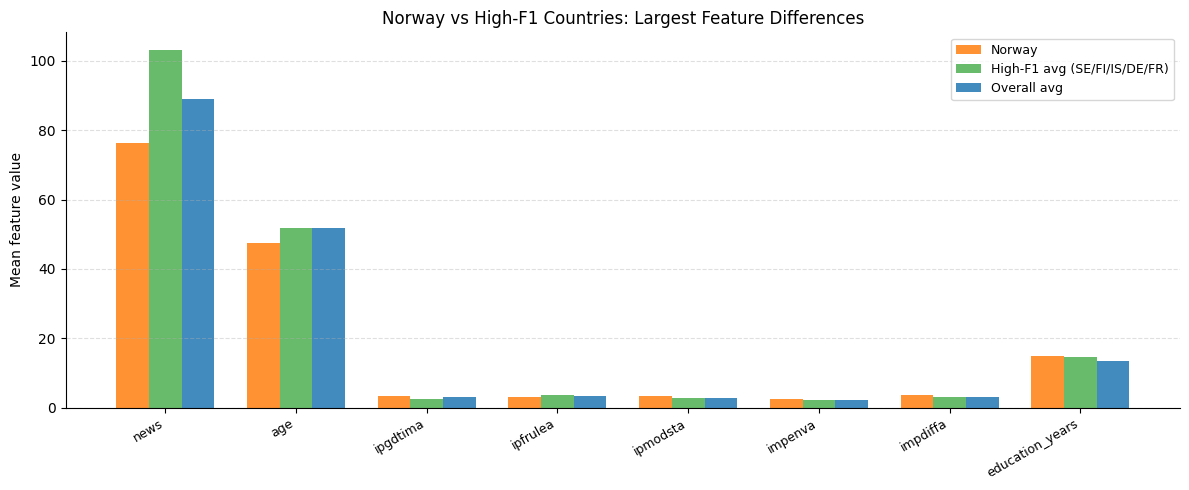

In [78]:
# -----------------------------
# 1. Correlation: Boycott Rate vs F1
# -----------------------------
from scipy import stats

r, p = stats.pearsonr(by_country["boycott_rate"], by_country["f1"])
rho, p_spearman = stats.spearmanr(by_country["boycott_rate"], by_country["f1"])

print("=== Prevalence–F1 Correlation ===")
print(f"Pearson  r  = {r:.3f}  (p = {p:.4f})")
print(f"Spearman rho = {rho:.3f}  (p = {p_spearman:.4f})")

# -----------------------------
# 2. Norway deep-dive
# -----------------------------
no_mask = results_clf[country_col] == "NO"
no_data = results_clf[no_mask].copy()

print(f"\n=== Norway Error Profile ===")
print(f"N samples:      {len(no_data)}")
print(f"Boycott rate:   {no_data['y_true'].mean():.3f}")
print(f"F1:             {f1_score(no_data['y_true'], no_data['y_pred']):.3f}")
print(f"Precision:      {precision_score(no_data['y_true'], no_data['y_pred']):.3f}")
print(f"Recall:         {recall_score(no_data['y_true'], no_data['y_pred']):.3f}")
print(f"FP rate:        {((no_data['y_true']==0) & (no_data['y_pred']==1)).mean():.3f}")
print(f"FN rate:        {((no_data['y_true']==1) & (no_data['y_pred']==0)).mean():.3f}")

# Compare NO feature means vs high-performing countries (SE, FI, IS, DE, FR)
high_performers = ["SE", "FI", "IS", "DE", "FR"]
high_mask = results_clf[country_col].isin(high_performers)

no_features    = results_clf.loc[no_mask,   numerical_cols].mean()
high_features  = results_clf.loc[high_mask, numerical_cols].mean()
overall_features = results_clf[numerical_cols].mean()

comparison = pd.DataFrame({
    "Norway":        no_features,
    "High-F1 avg":   high_features,
    "Overall avg":   overall_features,
}).T

print("\n=== Feature Means: Norway vs High-F1 Countries vs Overall ===")
print(comparison.round(3).to_string())

# Highlight where Norway deviates most from high-F1 countries
diff = (no_features - high_features).abs().sort_values(ascending=False)
print("\n=== Largest Feature Gaps: Norway vs High-F1 Countries ===")
print(diff.head(10).round(3).to_string())

# -----------------------------
# 3. Visualise: Norway vs High-F1 countries feature profile
# -----------------------------
top_diff_features = diff.head(8).index.tolist()

x = np.arange(len(top_diff_features))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x - width, no_features[top_diff_features],
       width=width, label="Norway", color="#ff7f0e", alpha=0.85)
ax.bar(x,         high_features[top_diff_features],
       width=width, label="High-F1 avg (SE/FI/IS/DE/FR)", color="#4CAF50", alpha=0.85)
ax.bar(x + width, overall_features[top_diff_features],
       width=width, label="Overall avg", color="#1f77b4", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(top_diff_features, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Mean feature value")
ax.set_title("Norway vs High-F1 Countries: Largest Feature Differences")
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.4, axis="y")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [79]:
print(by_country[["n_samples", "boycott_rate", "f1"]].sort_values("boycott_rate", ascending=False).round(3).to_string())

         n_samples  boycott_rate     f1
country                                
SE           224.0         0.558  0.726
FI           334.0         0.506  0.696
IS           165.0         0.412  0.640
DE           420.0         0.395  0.610
FR           342.0         0.395  0.582
CH           315.0         0.343  0.554
GB           290.0         0.252  0.510
NO           269.0         0.245  0.383
AT           466.0         0.238  0.498
IL           201.0         0.199  0.386
EE           242.0         0.194  0.419
ES           367.0         0.185  0.370
BE           311.0         0.183  0.360
GR           554.0         0.181  0.488
PL           243.0         0.152  0.301
ME           312.0         0.138  0.071
NL           338.0         0.133  0.394
SK           273.0         0.132  0.100
CY           132.0         0.121  0.083
LT           254.0         0.110  0.254
IE           389.0         0.103  0.264
SI           236.0         0.097  0.158
LV           232.0         0.095  0.346


=== Gender ===
              n_samples  boycott_rate     f1  precision  recall  fp_rate  fn_rate
gender_group                                                                     
Female           5123.0         0.184  0.516      0.434   0.638    0.187    0.362
Male             4481.0         0.188  0.478      0.405   0.583    0.199    0.417

=== Age ===
           n_samples  boycott_rate     f1  precision  recall  fp_rate  fn_rate
age_group                                                                     
18–34         1994.0         0.191  0.467      0.403   0.556    0.195    0.444
35–54         3139.0         0.199  0.500      0.412   0.636    0.225    0.364
55–74         3303.0         0.194  0.525      0.445   0.640    0.192    0.360
75+           1113.0         0.116  0.458      0.392   0.550    0.112    0.450

=== Education ===
                  n_samples  boycott_rate     f1  precision  recall  fp_rate  fn_rate
edu_group                                                        

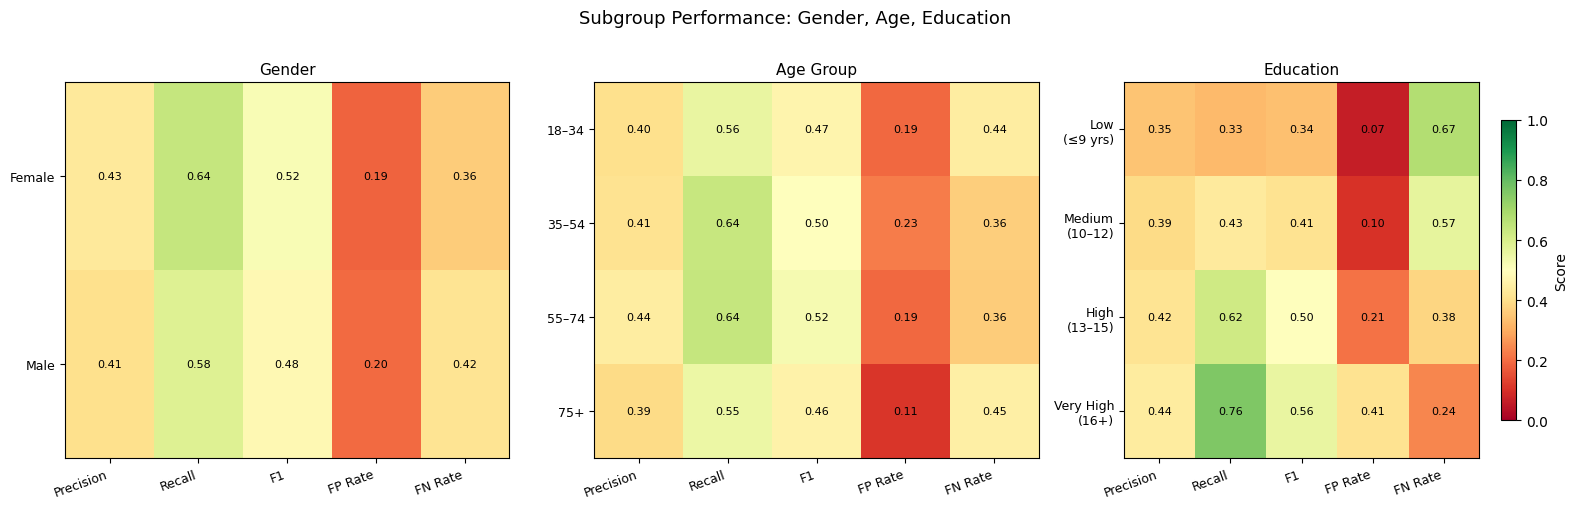

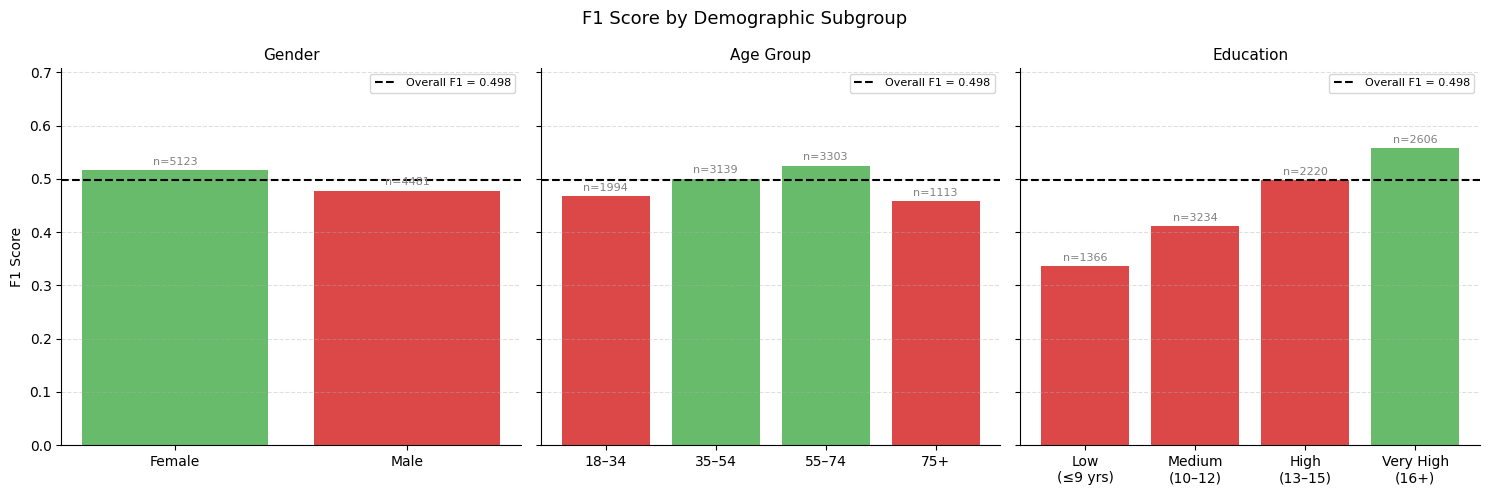


  SUBGROUP GAPS VS OVERALL F1

Gender:
  Female             F1=0.516  ▲ 0.018 vs overall
  Male               F1=0.478  ▼ 0.020 vs overall

Age Group:
  18–34              F1=0.467  ▼ 0.031 vs overall
  35–54              F1=0.500  ▲ 0.002 vs overall
  55–74              F1=0.525  ▲ 0.026 vs overall
  75+                F1=0.458  ▼ 0.040 vs overall

Education:
  Low
(≤9 yrs)       F1=0.336  ▼ 0.162 vs overall
  Medium
(10–12)     F1=0.412  ▼ 0.087 vs overall
  High
(13–15)       F1=0.498  ▼ 0.000 vs overall
  Very High
(16+)    F1=0.558  ▲ 0.059 vs overall


In [81]:
# -------------------------------------------------------
# SUBGROUP ANALYSIS — Gender, Age, Education
# -------------------------------------------------------

# -----------------------------
# STEP 1: Build analysis dataframe
# Adjust column names to match your actual ESS variable names
# -----------------------------
subgroup_df = X_holdout.copy().reset_index(drop=True)
subgroup_df["y_true"]  = y_holdout.reset_index(drop=True)
subgroup_df["y_pred"]  = y_holdout_pred
subgroup_df["y_proba"] = y_holdout_prob

# --- ESS variable names (adjust if yours differ) ---
gender_col = "gender"       # 1 = Male, 2 = Female
age_col    = "age"       # continuous age
edu_col    = "education_years"     # years of education (continuous)

# -----------------------------
# STEP 2: Create subgroup labels
# -----------------------------

# Gender
subgroup_df["gender_group"] = subgroup_df[gender_col].map({1: "Male", 2: "Female"})

# Age bins
subgroup_df["age_group"] = pd.cut(
    subgroup_df[age_col],
    bins=[0, 34, 54, 74, 120],
    labels=["18–34", "35–54", "55–74", "75+"]
)

# Education bins (years)
subgroup_df["edu_group"] = pd.cut(
    subgroup_df[edu_col],
    bins=[-1, 9, 12, 15, 50],
    labels=["Low\n(≤9 yrs)", "Medium\n(10–12)", "High\n(13–15)", "Very High\n(16+)"]
)

# -----------------------------
# STEP 3: Helper — compute metrics per group
# -----------------------------
def group_metrics(df):
    yt = df["y_true"]
    yp = df["y_pred"]
    n_pos = yt.sum()
    n_neg = (yt == 0).sum()

    if n_pos < 3 or n_neg < 3:
        return None

    return pd.Series({
        "n_samples":    len(df),
        "boycott_rate": yt.mean(),
        "f1":           f1_score(yt, yp, zero_division=0),
        "precision":    precision_score(yt, yp, zero_division=0),
        "recall":       recall_score(yt, yp, zero_division=0),
        "fp_rate":      ((yt == 0) & (yp == 1)).sum() / max(n_neg, 1),
        "fn_rate":      ((yt == 1) & (yp == 0)).sum() / max(n_pos, 1),
    })

# Compute per subgroup
gender_metrics = subgroup_df.groupby("gender_group").apply(group_metrics).dropna()
age_metrics    = subgroup_df.groupby("age_group", observed=True).apply(group_metrics).dropna()
edu_metrics    = subgroup_df.groupby("edu_group",  observed=True).apply(group_metrics).dropna()

print("=== Gender ===");  print(gender_metrics.round(3).to_string())
print("\n=== Age ===");    print(age_metrics.round(3).to_string())
print("\n=== Education ==="); print(edu_metrics.round(3).to_string())

# -----------------------------
# STEP 4: Heatmap per subgroup variable
# Mirrors lecture section 4.3 style
# -----------------------------
metrics_to_show = ["precision", "recall", "f1", "fp_rate", "fn_rate"]
metric_labels   = ["Precision", "Recall", "F1", "FP Rate", "FN Rate"]

subgroups = {
    "Gender":    gender_metrics,
    "Age Group": age_metrics,
    "Education": edu_metrics,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (title, metrics_df) in zip(axes, subgroups.items()):
    data = metrics_df[metrics_to_show].astype(float)

    im = ax.imshow(data.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)

    ax.set_xticks(range(len(metrics_to_show)))
    ax.set_xticklabels(metric_labels, fontsize=9, rotation=20, ha="right")
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data.index.astype(str), fontsize=9)
    ax.set_title(title, fontsize=11)

    # Annotate cells
    for i in range(len(data)):
        for j in range(len(metrics_to_show)):
            val = data.values[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=8, color="black")

plt.colorbar(im, ax=axes[-1], label="Score", shrink=0.8)

# Overall baseline row reference line
fig.suptitle("Subgroup Performance: Gender, Age, Education", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# -----------------------------
# STEP 5: Bar chart — F1 across subgroups side by side
# Easy to compare against overall baseline
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (title, metrics_df) in zip(axes, subgroups.items()):
    groups  = metrics_df.index.astype(str)
    f1_vals = metrics_df["f1"].values
    colors  = ["#4CAF50" if v >= overall_f1 else "#d62728" for v in f1_vals]

    ax.bar(groups, f1_vals, color=colors, alpha=0.85)
    ax.axhline(overall_f1, color="black", linestyle="--", linewidth=1.5,
               label=f"Overall F1 = {overall_f1:.3f}")

    # Annotate with sample size
    for i, (g, row) in enumerate(metrics_df.iterrows()):
        ax.text(i, f1_vals[i] + 0.01, f"n={int(row['n_samples'])}",
                ha="center", fontsize=8, color="grey")

    ax.set_title(title, fontsize=11)
    ax.set_ylabel("F1 Score") if ax == axes[0] else None
    ax.set_ylim(0, max(f1_vals.max() + 0.15, overall_f1 + 0.15))
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4, axis="y")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("F1 Score by Demographic Subgroup", fontsize=13)
plt.tight_layout()
plt.show()

# -----------------------------
# STEP 6: Print gaps vs overall
# -----------------------------
print(f"\n{'='*45}")
print("  SUBGROUP GAPS VS OVERALL F1")
print(f"{'='*45}")
for title, metrics_df in subgroups.items():
    print(f"\n{title}:")
    for group, row in metrics_df.iterrows():
        gap = row["f1"] - overall_f1
        direction = "▲" if gap >= 0 else "▼"
        print(f"  {str(group):<18} F1={row['f1']:.3f}  {direction} {abs(gap):.3f} vs overall")